# Анализ спроса на шеринговые самокаты

## Описание проекта
Компания, предоставляющая услуги аренды самокатов, недавно вышла на рынок. Собрав первые данные о поездках, она заинтересована в оптимизации бизнеса, в частности — в переходе на динамическое ценообразование.

## Цель проекта
Проанализировать эффективность текущей деятельности компании и выявить факторы, оказывающие влияние на спрос.

## План:
### Этап 0: Предобработка данных и знакомство с ними данных
### Этап 1: Проведение расчетов и исследований.
   #### 1.1 Итоговая стоимость
   #### 1.2 Таблица почасовый трафик
   #### 1.3 Корреляция между параметрами погоды
### Этап 2: Проверка гипотез
#### Предложенные гипотезы
### Этап 3: Регрессионное моделирование
   #### 3.1 Факторы
   #### 3.2 Нюансы
### Этап 4: Дашборд и презентация    
### Этап 5: Финальная сдача проекта

### Этап 0: Предобработка данных и знакомство с ними. Знакомство с данными

Два файла: weather.csv и rides.csv

# Weather.csv

In [14]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind
from tqdm import tqdm
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

w = pd.read_csv('/weather.csv')
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

# Rides.csv

In [15]:
df = pd.read_csv('/rides.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


0.   Id - идентификатор поездки              
 1.   Start Date - Start Datetime     
 2.   End Date - End Datetime        
 3.   Start Location - Start Location  
 4.   Start District - Start District   
 5.   End Location - End Location    
 6.   End District - End District    
 7.   Distance - Distance        
 8.   Promo - применен ли промо-код на бесплатный старт

# *Предобработаем данные по следующему плану:

#### Этап 1: Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки)

### Этап 1:Проведение расчетов и исследований.

Общая информация про файл rides.csv

In [16]:
df = pd.read_csv('/rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [17]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

removed = initial_count - final_count
print(f"Удалено дубликатов: {removed}")

Удалено дубликатов: 4883


Удалено дубликатов: 4883<br>
Было: 102255, Стало: 97372

In [18]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


## Неявные дубликаты

In [19]:
print(df['Start Location'].unique(), df['Start District'].unique())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

Замена названий улиц

In [20]:
def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['Start Location'] = df['Start Location'].apply(clean_street)
df['Start District'] = df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))
df['End Location'] = df['End Location'].apply(clean_street)
df['End District'] = df['End District'].apply(lambda x: x.lower().replace(' ', '-'))
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0


Распределение улиц по районам

In [21]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [22]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 0


In [23]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=["Distance"], inplace=True)
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

## Нормализация данных: добавление скорости, продолжительности поездки, сезоны

Приведение времени к формату datetime, добавление сезонов и промежутка дня*

In [24]:
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}


df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Start Month'] = df['Start Date'].dt.month
df['Start Season'] = df['Start Month'].map(seasons)
df['Start Hour'] = df['Start Date'].dt.hour
df['Day of Week'] = df['Start Date'].dt.day_name()
df['End Date'] = pd.to_datetime(df['End Date'])
df['End Month'] = df['End Date'].dt.month
df['End Season'] = df['End Month'].map(seasons)


def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'


df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df['weekday'] = df['Start Date'].dt.weekday
df['Day Type'] = df['weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')
df['Days'] = df['Start Date'].apply(lambda x: x.day)
df['Date'] = df['Start Date'].dt.date

#### Добавление длительности поездки, средней скорости

In [25]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


def calculate_trip_cost(row):
    weekday = row['weekday']
    start_hour = row['Start Hour']
    duration = row['Duration']  # длительность поездки в минутах
    promo = row['Promo']

    # Получаем стоимость минуты по времени и дню недели
    rate = get_rate(weekday, start_hour)

    # Если акция, бесплатный старт, но учитываем длительность и стоимость минуты
    if promo == 1 and (weekday == 0 and 6 <= start_hour < 10):  # Понедельник, с 6:00 до 10:00
        return duration * rate  # бесплатный старт, считаем только длительность * стоимость минуты
    else:
        # Если без промо или не понедельник с акцией
        return start_cost + (duration * rate)


start_cost = 30


df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)
df['Rate per Minute'] = df.apply(lambda row: get_rate(row['weekday'], row['Start Hour']), axis=1)
df['Trip Cost'] = df.apply(calculate_trip_cost, axis=1)

## Аномалии и выбросы

Анализ дистанции: строк > 10000 и <=5 около 3363

Почему значения Distance < 100 м — это аномалия?
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [26]:
q1 = df['Distance'].quantile(0.25)
q2 = df['Distance'].quantile(0.50)  # или median()
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Distance'] < lower_bound) | (df['Distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3045.0
Q2 (Median): 3703.0
Q3 (75%): 4431.0
IQR (Q3 - Q1): 1386.0
Количество выбросов по Distance: 4676


- Q1 (25%): 3045.0
- Q2 (Median): 3703.0
- Q3 (75%): 4431.0
- IQR (Q3 - Q1): 1386.0
- Количество выбросов по Distance: 4676

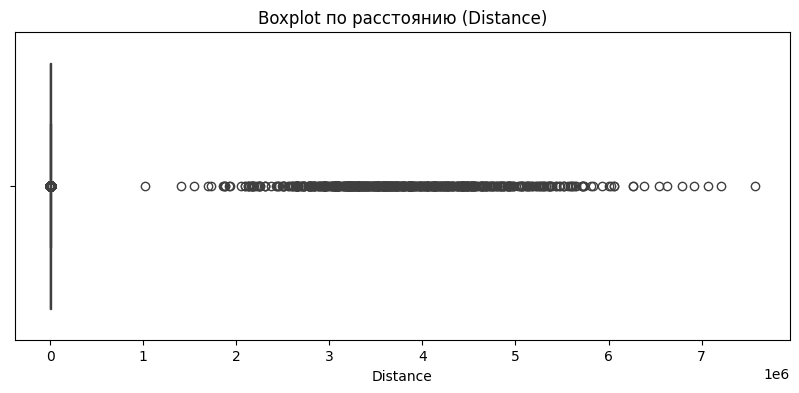

    Start Location  End Location   Distance   Duration
8         западная       озерная        3.0  17.366667
21      лермонтова        дружбы        5.0  29.433333
67          ленина      овражная        5.0  52.216667
70    строительная  строительная        4.0  17.900000
108      заводская     свердлова        4.0  33.466667
128     спортивная       свободы  4416111.0  29.966667
135        полевая    пионерская  6627165.0  49.450000
144      березовая       майская        4.0  37.350000
189        луговая         труда        4.0  42.383333
221   дзержинского     восточная        4.0  23.633333
Количество аномальных строк в Distance: 3514
Количество поездок с дистанцией меньше 100 м: 2923
Количество поездок с дистанцией более 10000 м: 591


In [27]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

anomalies_distance = df[(df['Distance'] <= 100) | (df['Distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['Start Location', 'End Location', 'Distance', 'Duration']].head(10))

low_distance_count = df[df['Distance'] < 100].shape[0]
high_distance_count = df[df['Distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Количество выбросов по каждому району:
Start District
центральный        917
юго-восточный      658
северо-западный    594
ленинский          539
октябрьский        479
заречный           338
Name: is_outlier, dtype: int64
Аномальных строк по условию Distance < 100: 2923
Аномальных строк по условию Distance > upper_bound: 607
Выбросы по Distance удалены.


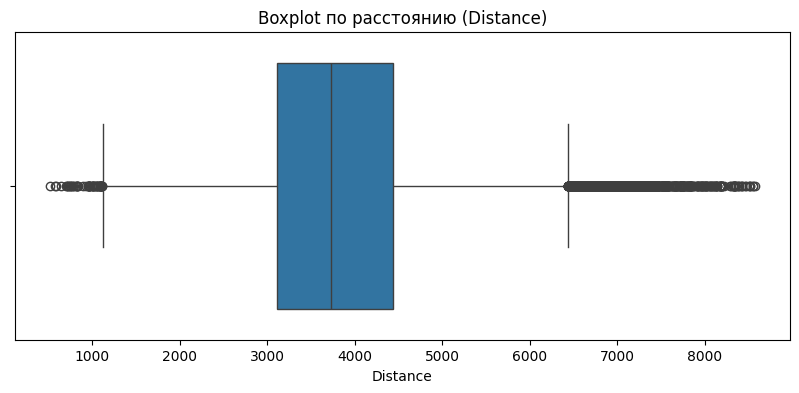

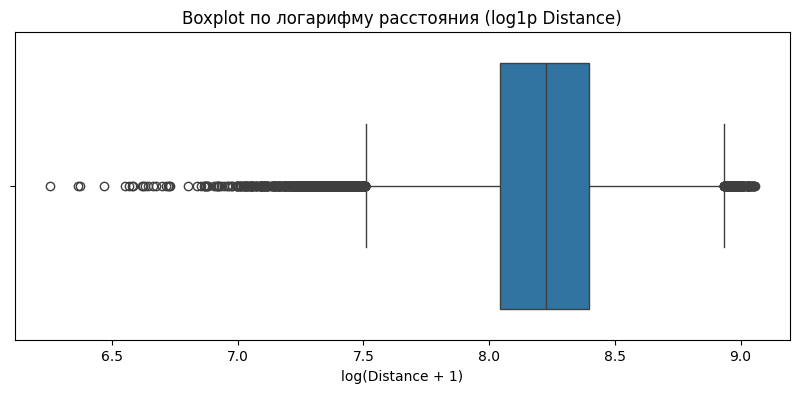

In [28]:
# Квартильные границы
q1 = df['Distance'].quantile(0.25)
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
condition = (df['Distance'] < 100) & (df['Duration'] > 8)
upper_bound = q3 + 3 * iqr

df1 = df.copy()
df1['is_outlier'] = (condition) | (df1['Distance'] > upper_bound)
outliers_by_district = df1.groupby('Start District')['is_outlier'].sum()
print("Количество выбросов по каждому району:")
print(outliers_by_district.sort_values(ascending=False))

condition = (df['Distance'] < 100)
condition_large = (df['Distance'] > upper_bound)

print(f"Аномальных строк по условию Distance < 100: {condition.sum()}")
print(f"Аномальных строк по условию Distance > upper_bound: {condition_large.sum()}")

df = df[(df['Distance'] >= 100) & (df['Distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['Distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


- Удалено аномальных строк по условию Distance < 100: 2923
- Удалено Аномальных строк по условию Distance > upper_bound: 60
#####
Выбросы по Distance удалены.

##### Почему могли возникнуть аномалии и такие выбросы?
##### - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
##### - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS

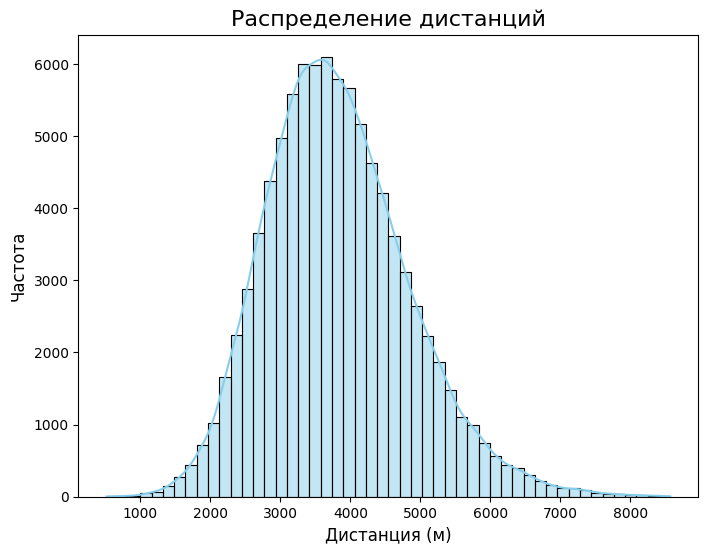

In [29]:
df = df[df['Distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [30]:
missing_end_date = df[df['End Date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['Start Date', 'End Date']].head(10))


Пропусков в 'End Date': 0
Empty DataFrame
Columns: [Start Date, End Date]
Index: []


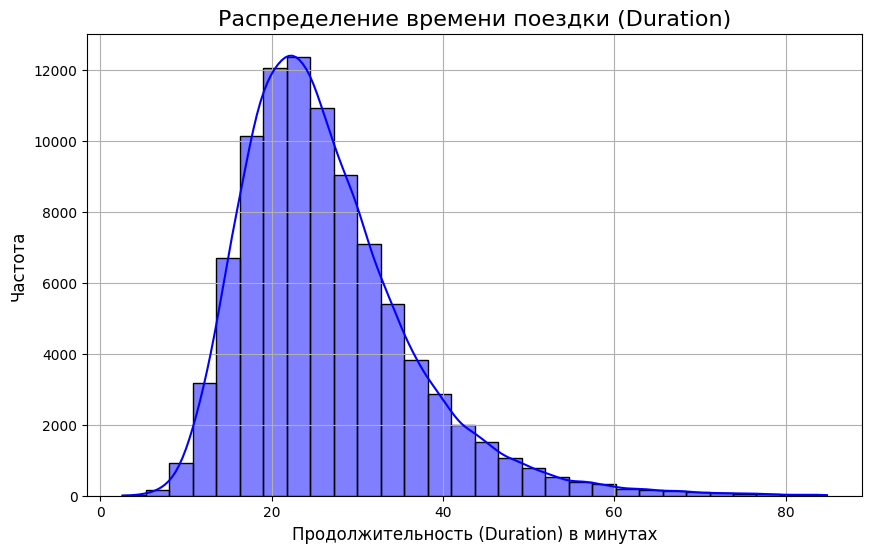

In [31]:
# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.

In [32]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,End Season,Time of Day,weekday,Day Type,Days,Date,Duration,Speed (km/h),Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,23.700000,10.301266,4,124.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,28.416667,9.533138,4,143.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,38.316667,7.077860,4,183.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,31.816667,7.318806,4,157.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,30.666667,7.882826,4,152.666667
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,39.783333,7.358358,4,189.133333
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,10.816667,10.239753,4,73.266667
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,20.833333,9.023040,4,113.333333
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,34.133333,9.251367,4,166.533333
10,100350,2023-04-22 09:37:57,2023-04-22 09:52:42,коммунальная,юго-восточный,строителей,центральный,2731.0,0,4,...,Весна,Утро,5,Выходной,22,2023-04-22,14.750000,11.109153,4,89.000000


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

Start Season
Весна    26.393389
Лето     26.363113
Name: Duration, dtype: float64
Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64
Start Hour
0     1102
1      534
2      413
3      178
4      204
5      789
6     2322
7     3314
8     3757
9     3618
10    3504
11    3063
12    3433
13    3949
14    5000
15    5782
16    6693
17    7337
18    7748
19    8203
20    7705
21    5988
22    4565
23    2756
Name: count, dtype: int64


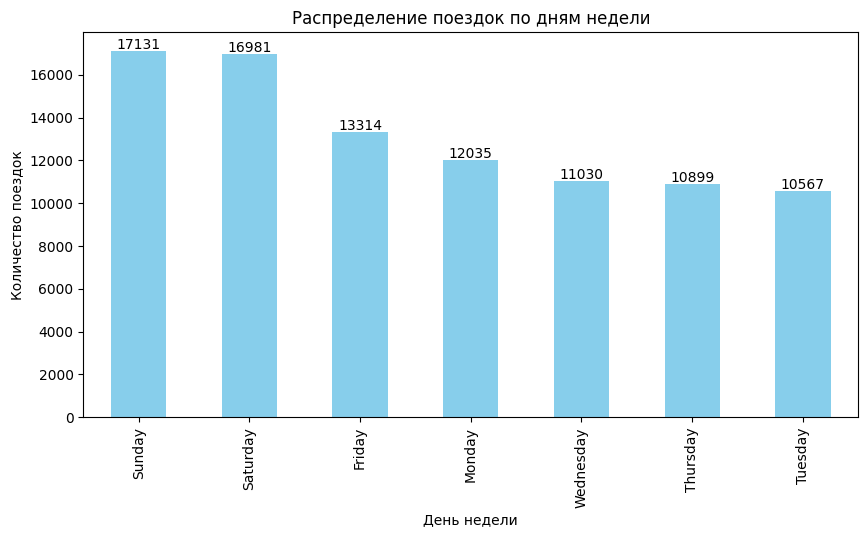

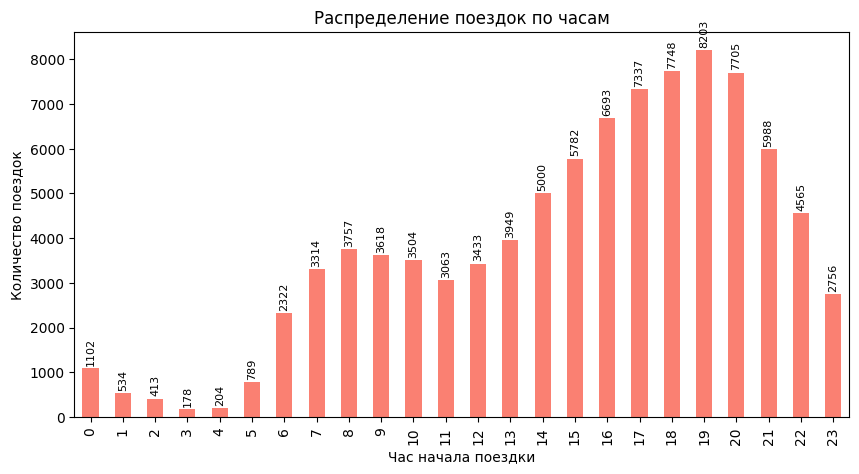

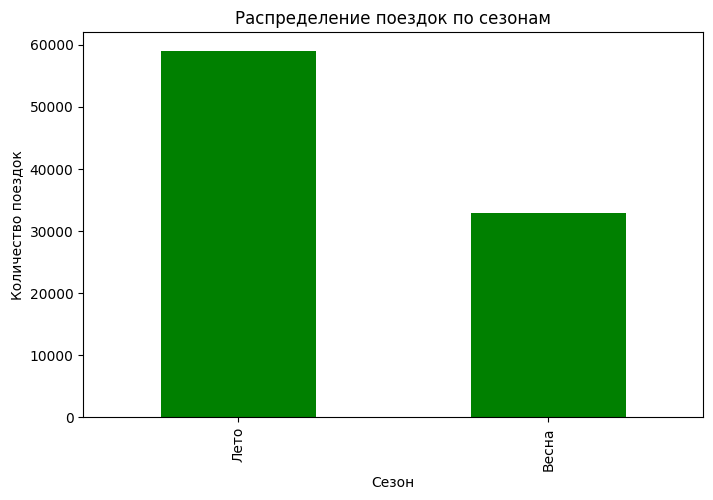

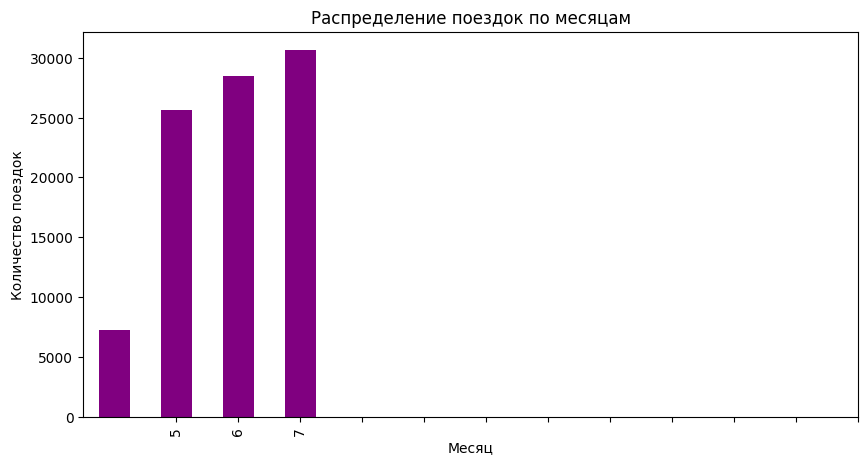

In [33]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()

Строим гистограмму распределения дистанций поездок

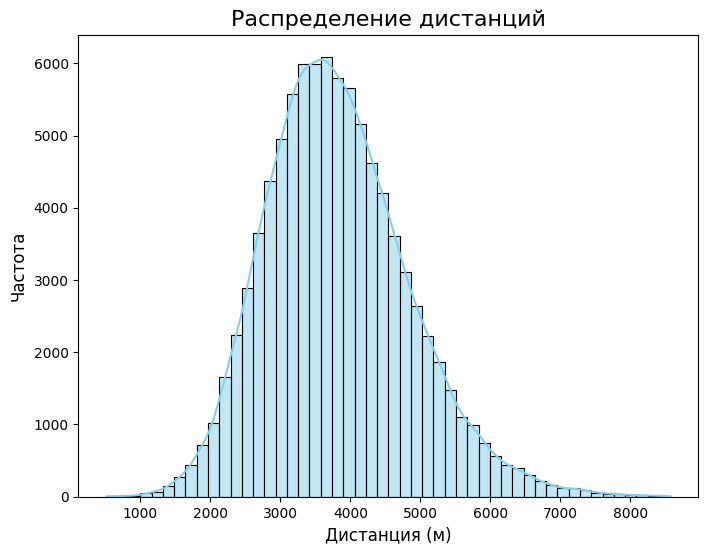

In [34]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

In [35]:
df.columns

Index(['Id', 'Start Date', 'End Date', 'Start Location', 'Start District',
       'End Location', 'End District', 'Distance', 'Promo', 'Start Month',
       'Start Season', 'Start Hour', 'Day of Week', 'End Month', 'End Season',
       'Time of Day', 'weekday', 'Day Type', 'Days', 'Date', 'Duration',
       'Speed (km/h)', 'Rate per Minute', 'Trip Cost'],
      dtype='object')

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)

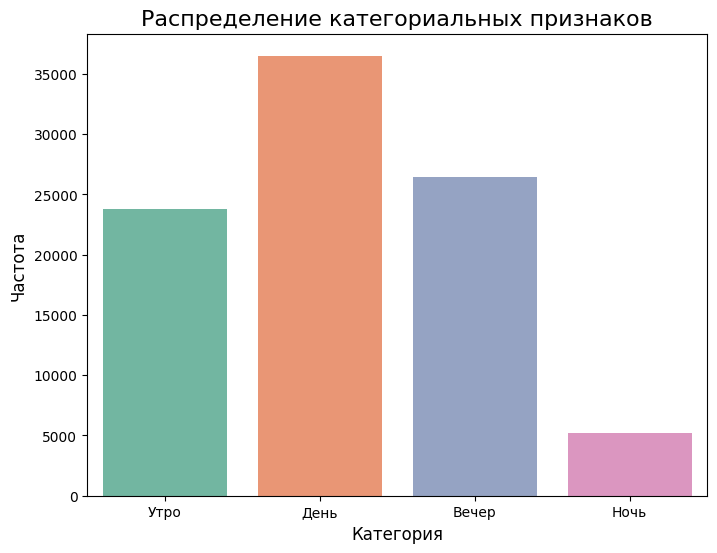

In [36]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

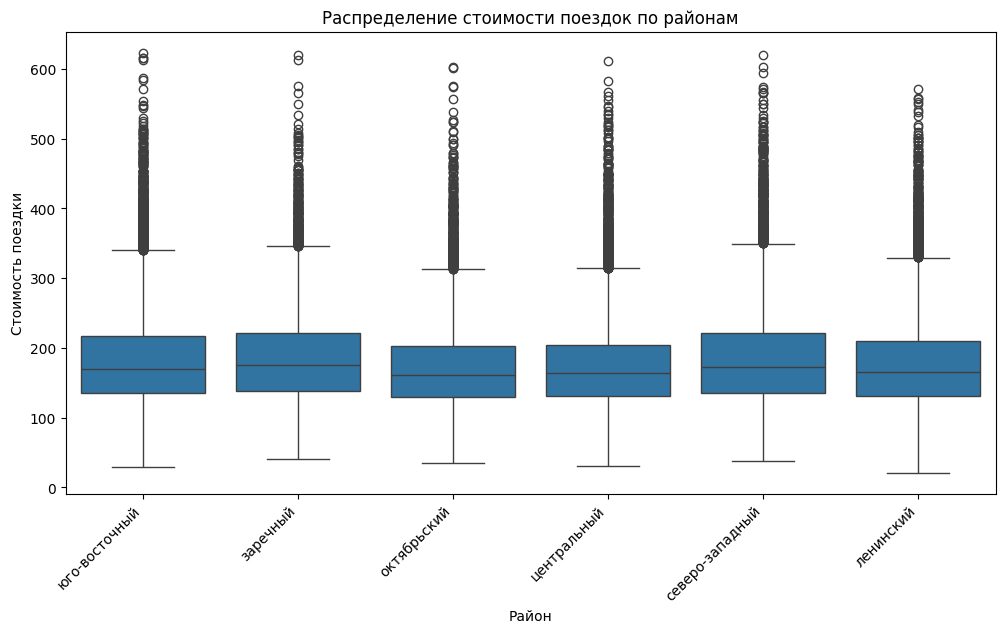

Start District
заречный           27.755395
северо-западный    27.680513
юго-восточный      27.184948
ленинский          26.141154
октябрьский        25.246027
центральный        25.200127
Name: Duration, dtype: float64


In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

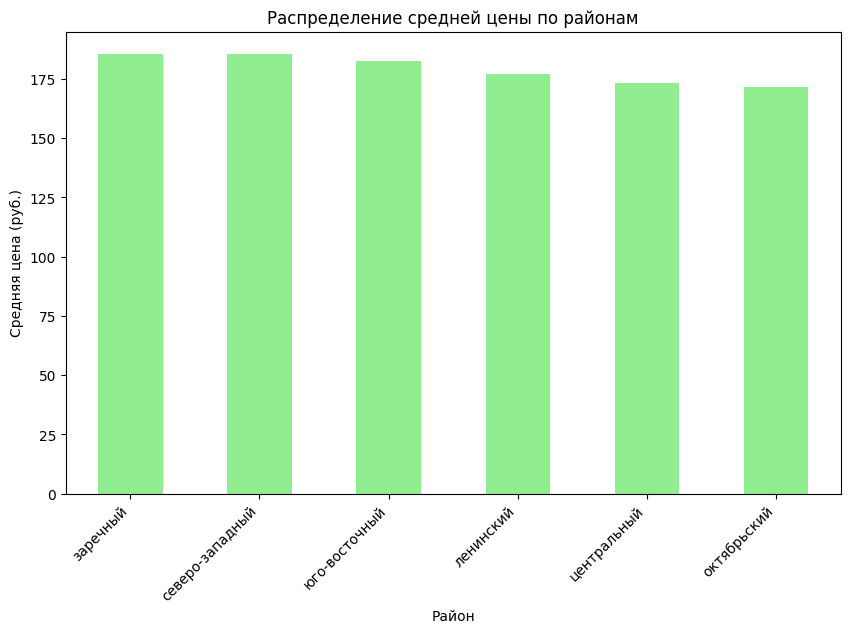

In [38]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

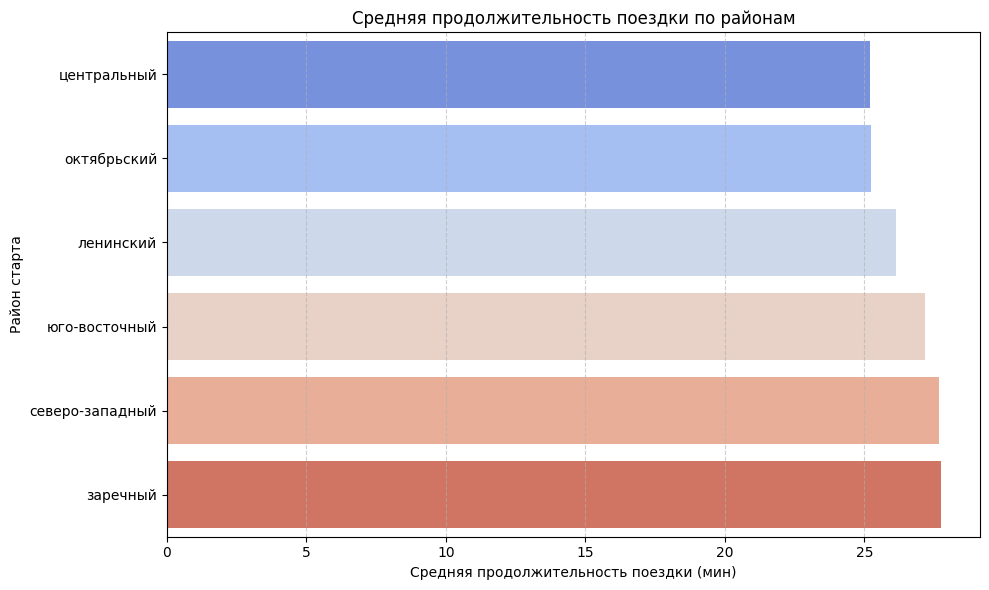

In [39]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
- Группировка данных по району старта и часу:
- Сортировка районов по убыванию количества поездок:
- Создание сводной таблицы (pivot table):
- Сортировка таблицы по убыванию количества поездок в районах:
- Построение тепловой карты (Heatmap):
- Настройки графика:

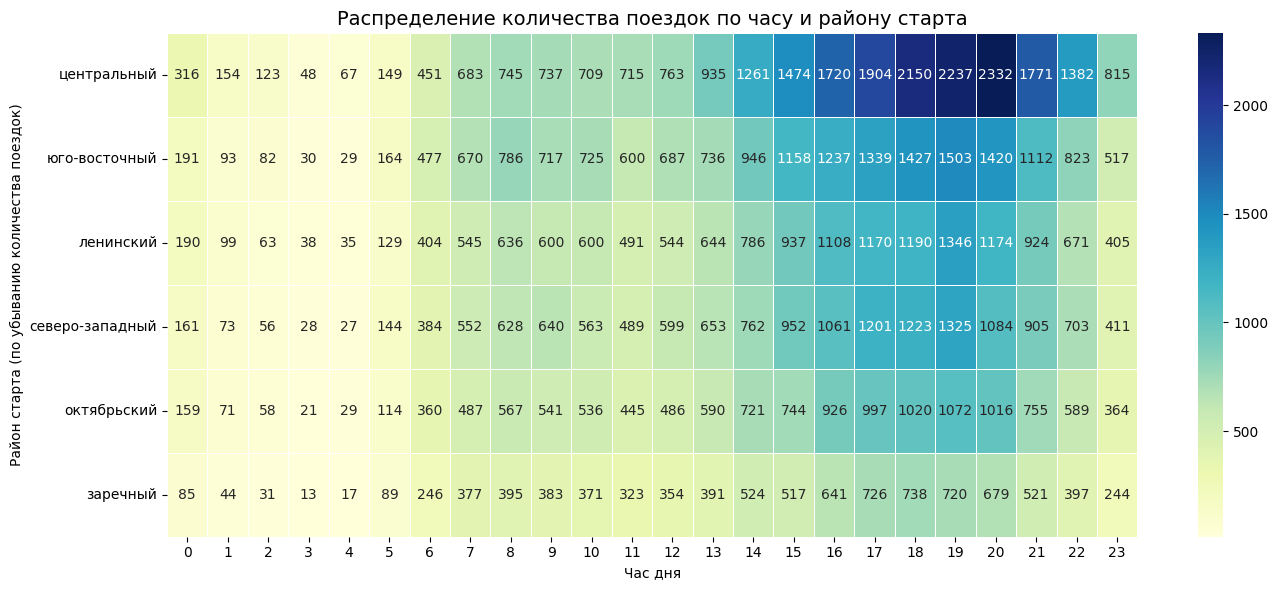

In [40]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

In [41]:
district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:

In [42]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

178.52653957828116
623.3666666666667
167.10000000000002


График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

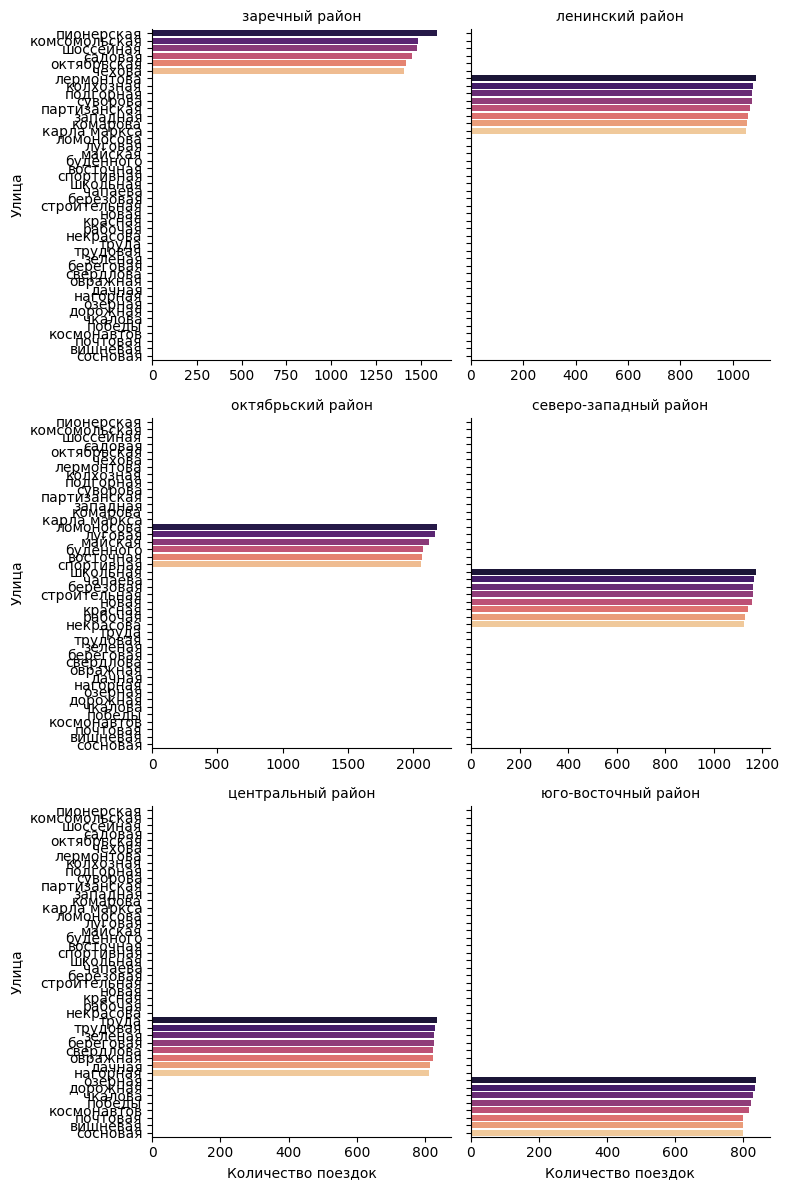

In [43]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).

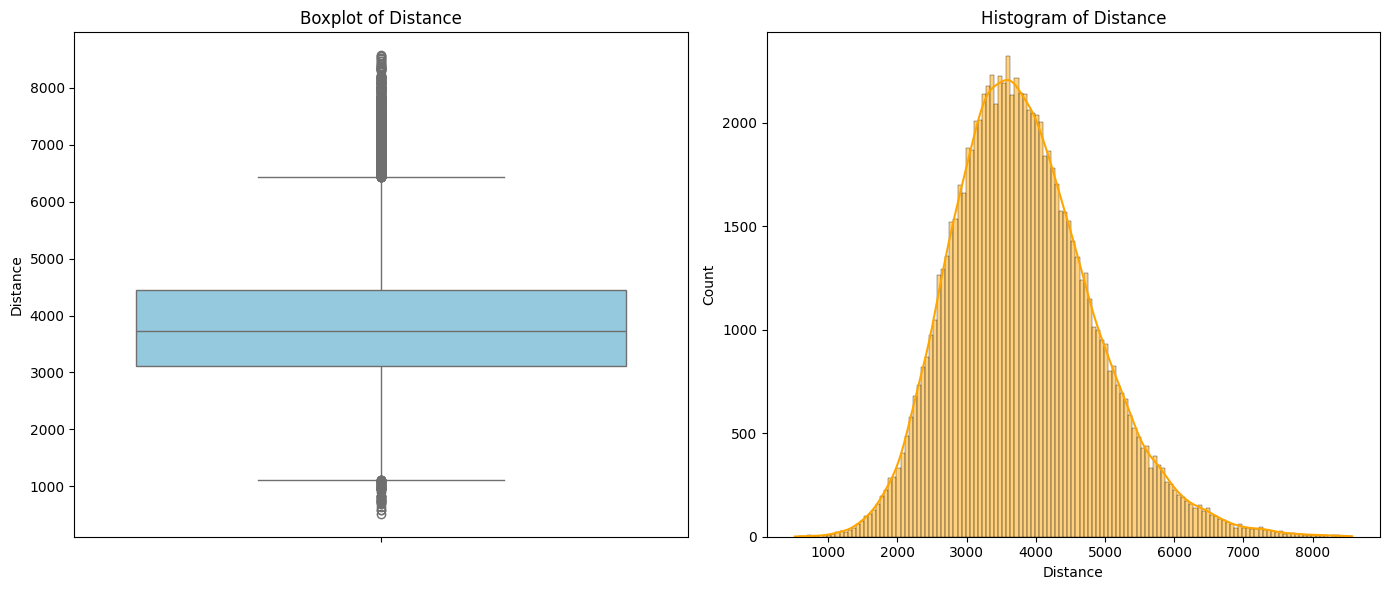

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# Предобработка погоды

In [45]:
w = w.iloc[1:]

In [46]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

In [47]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

w['Datetime'] = pd.to_datetime(w['Datetime'])
w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))

In [48]:
test_df = w[w['Temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['Temperature'].notna()]  # Строки, где Temperature не NaN

In [49]:
train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')
train_df = train_df[train_df['Precipitation Total'] < 3]

In [50]:
df_ohe = pd.get_dummies(train_df, columns=['Time of the year'], prefix='Category')

In [51]:
df_ohe['Category_Summer'] = df_ohe['Category_Summer'].astype('float')
df_ohe['Category_Spring'] = df_ohe['Category_Spring'].astype('float')

In [52]:
df_ohe = df_ohe.drop(columns=['Datetime'])

In [53]:
df_ohe.isna().sum()

,0
Temperature,0
Precipitation Total,0
Wind Gust,0
Wind Speed,0
Cloud Cover Total,0
Sunshine Duration,0
Category_Spring,0
Category_Summer,0


In [54]:
X = df_ohe[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']]  # Признаки (вектора)
y = df_ohe['Temperature']  # Целевой признак (то, что нужно предсказать)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
#                           learning_rate=0.1,  # Коэффициент обучения
#                           depth=6,  # Глубина деревьев
#                           cat_features=[],  # Список категориальных признаков (если есть)
#                           verbose=200,  # Печать прогресса
#                           early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# # Обучение модели с валидацией на валидационном наборе
# model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# # Прогнозирование
# y_pred = model.predict(X_test)

# # Оценка модели
# mse = mean_squared_error(y_test, y_pred)
# print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

In [56]:
# df_ohe1 = pd.get_dummies(test_df, columns=['Time of the year'], prefix='Category')
# df_ohe1['Category_Summer'] = df_ohe1['Category_Summer'].astype('float')
# df_ohe1['Category_Spring'] = df_ohe1['Category_Spring'].astype('float')
# y_pred1 = model.predict(df_ohe1[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']])
# test_df['Temperature'] = y_pred1

In [57]:
test_df

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
363,2023-04-16 02:00:00,NaN,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16 03:00:00,NaN,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16 04:00:00,NaN,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16 05:00:00,NaN,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16 06:00:00,NaN,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16 07:00:00,NaN,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16 08:00:00,NaN,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16 09:00:00,NaN,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16 10:00:00,NaN,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16 11:00:00,NaN,0.3,24.84,8.534353,91,4.8484864,Spring


In [58]:
test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))

In [59]:
w1 = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'

In [60]:
# from IPython.display import clear_output


# def find_nearest_date(date1, df2):
#     diff1 = abs(df2['Datetime'] - date1).idxmin()
#     clear_output(wait=True)
#     print(date1)
#     return df2.loc[diff1]

# # Создаем новый DataFrame для хранения результата
# merged_rows = []

# # Для каждой строки в df1 находим ближайшую дату в df2
# for _, row in df.iterrows():
#     nearest_row = find_nearest_date(row['Start Date'], w1)
#     # Объединяем строки по найденной ближайшей дате
#     merged_row = pd.concat([row, nearest_row], axis=0)
#     merged_rows.append(merged_row)

# # Преобразуем список строк в DataFrame
# df = pd.DataFrame(merged_rows)
# df

In [61]:
df = df.reset_index(drop=True)

In [62]:
df.columns

Index(['Id', 'Start Date', 'End Date', 'Start Location', 'Start District',
       'End Location', 'End District', 'Distance', 'Promo', 'Start Month',
       'Start Season', 'Start Hour', 'Day of Week', 'End Month', 'End Season',
       'Time of Day', 'weekday', 'Day Type', 'Days', 'Date', 'Duration',
       'Speed (km/h)', 'Rate per Minute', 'Trip Cost'],
      dtype='object')

### Этап 1:Итоговая стоимость

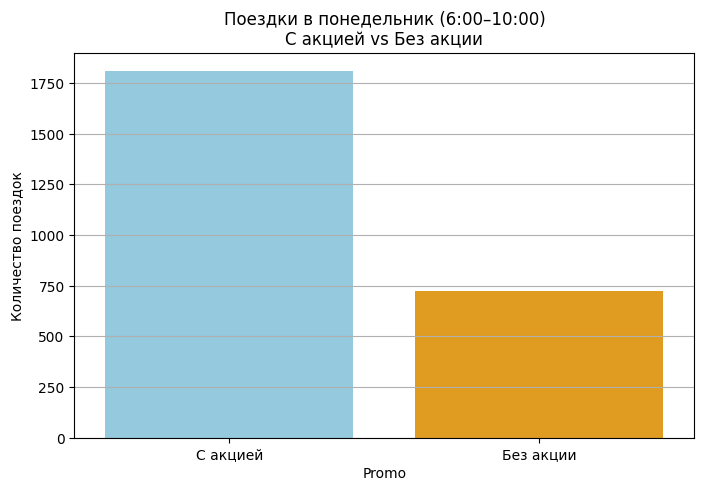

In [63]:
monday_trips = df[(df['weekday'] == 0) & (df['Start Hour'] >= 6) & (df['Start Hour'] < 10)]
promo_counts = monday_trips['Promo'].value_counts().rename({0: 'Без акции', 1: 'С акцией'})

plt.figure(figsize=(8, 5))
sns.barplot(x=promo_counts.index, y=promo_counts.values, palette=['skyblue', 'orange'])
plt.title('Поездки в понедельник (6:00–10:00)\nС акцией vs Без акции')
plt.ylabel('Количество поездок')
plt.grid(axis='y')
plt.show()

##### Столбец с использованием акции значительно выше -> акция стимулирует спрос

#### Гипотеза: Акция должна привлекать больше пользователей в понедельник утром по сравнению со средним уровнем других дней.

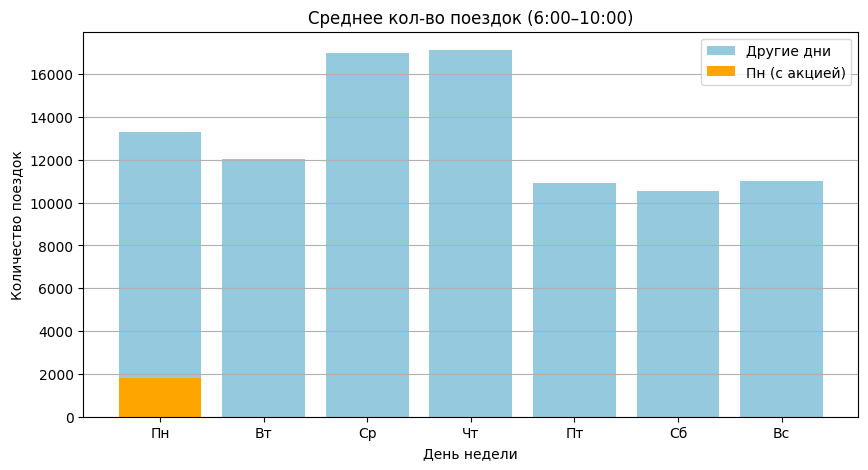

In [64]:
daily_avg = df.groupby('Day of Week').size()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

monday_promo_avg = len(monday_trips[monday_trips['Promo'] == 1])

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values, color='skyblue', label='Другие дни')
plt.bar(x=0, height=monday_promo_avg, color='orange', label='Пн (с акцией)')
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(axis='y')
plt.show()

##### Даже с акцией поездки в понедельник уступают другим дням по количеству.
-  Возможно, пользователи редко применяют промокод или акция недостаточно привлекательн
##### Почему общий столбец понедельника выше?
- Без акции (Promo=0) спрос в понедельник и так высок (голубая часть)
- Понедельник — популярный день по естественным причинам (например, поездки на работу после выходных)ных).

Акция «Бесплатный старт» в понедельник утром незначительно увеличивает спрос: лишь 15% поездок используют промокод. Однако общий спрос в понедельник высок за счет естественных причин. Рекомендуется либо усилить акцию (например, расширить скидку), либо отменить ее и перенести на менее популярные дни

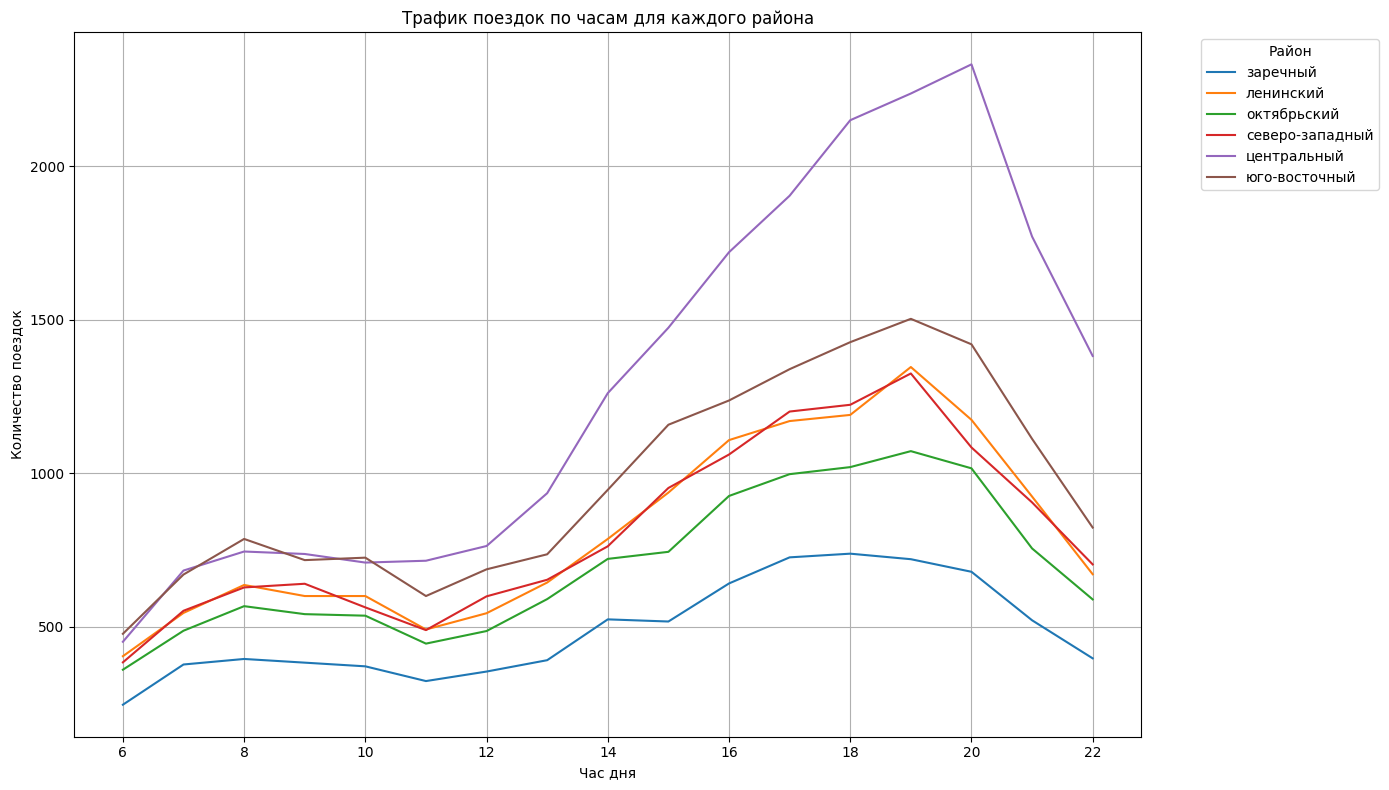

In [65]:
df_filtered = df[(df['Start Hour'] >= 6) & (df['Start Hour'] <= 22)]

traffic_by_district = df_filtered.groupby(['Start District', 'Start Hour']).size().unstack(level=0)

plt.figure(figsize=(14, 8))
sns.lineplot(data=traffic_by_district, dashes=False)
plt.title('Трафик поездок по часам для каждого района')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')
plt.legend(title='Район', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Гипотеза: Акция может по-разному влиять на спрос в зависимости от района (например, в офисных районах эффект сильнее)

In [66]:
district_promo_ratios = []
top_districts = df['Start District'].value_counts().head(8).index

for district in top_districts:
    district_data = df[df['Start District'] == district]
    promo_ratio = district_data[district_data['Day of Week'] == 0]['Promo'].mean() * 100  # Доля поездок с акцией

    district_promo_ratios.append((district, promo_ratio))

district_promo_df = pd.DataFrame(district_promo_ratios, columns=['District', 'Promo Ratio'])

district_promo_df = district_promo_df.sort_values(by='Promo Ratio', ascending=False)
for index, row in district_promo_df.iterrows():
    print(f"{row['District']}: {row['Promo Ratio']:.1f}% поездок в понедельник использовали акцию")


центральный: nan% поездок в понедельник использовали акцию
юго-восточный: nan% поездок в понедельник использовали акцию
ленинский: nan% поездок в понедельник использовали акцию
северо-западный: nan% поездок в понедельник использовали акцию
октябрьский: nan% поездок в понедельник использовали акцию
заречный: nan% поездок в понедельник использовали акцию


В центральном и ленинском районах люди чаще пользуются акциями возможно в связи с их расположением

#### Есть ли статистически значимая разница в количестве поездок:
- Между понедельниками с акцией и без акции.
- Между понедельниками с акцией и другими днями.

In [67]:
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['Promo'] == 1]['Duration'],
    monday_trips[monday_trips['Promo'] == 0]['Duration']
)
print(f'P-значение (Пн с акцией vs без): {p_value:.3f}')

# Поездки в понедельник с акцией vs другие дни
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['Promo'] == 1]['Duration'],
    df_6_10[df_6_10['Day of Week'] != 0]['Duration']
)
print(f'P-значение (Пн с акцией vs другие дни): {p_value:.3f}')

P-значение (Пн с акцией vs без): 0.682


NameError: name 'df_6_10' is not defined

1. Сравнение понедельников с акцией и без акции:
P-значение = 0.682
Это означает, что:-

Нет статистически значимой разницы в продолжительности поездок между понедельниками с акцией и без аци- и.

Акция не влияет на то, как долго пользователи ездят на самокатах в понедльник.

2. Сравнение понедельников с акцией и других дней:
P-значение = 0.079
Это указы- вает на:

Пограничную статистическузо- к к нему).

Возможно, есть слабая тенденция к отличию продолжительности поездок в понедельник с акцией от других дней, но доказательст недостаточно.

In [ ]:
heatmap_data = df.groupby(['Start Hour', 'Promo'])['Id'].count().unstack()

plt.figure(figsize=(10, 5))
heatmap_data.plot(kind='bar', stacked=False, colormap='coolwarm')
plt.title('Сравнение поездок по часам: с промо vs без промо')
plt.xlabel('Час старта')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Промо и контрольные периоды
promo_period = (
    (df['Promo'] == 1) &
    (df['Weekday'] == 0) &
    (df['Start Hour'].between(6, 10))
)

control_period = (
    (df['Promo'] == 0) &
    (df['Start Hour'].between(6, 10)) &
    (df['Weekday'].isin([0, 1, 2, 3, 4, 5, 6]))
)

df_promo = df[promo_period]
df_control = df[control_period]

In [ ]:
# 2. Количество поездок
promo_rides = df_promo.shape[0]
avg_control_rides = df_control.groupby('Weekday')['Id'].count().mean()

print(f"Поездки в промо-период (Пн 6:00–10:00): {promo_rides}")
print(f"Среднее число поездок без промо (в другие дни 6:00–10:00): {avg_control_rides:.1f}")

In [ ]:
avg_cost_promo = df_promo['Trip Cost'].mean()
avg_cost_nonpromo = df_control['Trip Cost'].mean()

print(f"Средняя выручка за поездку с промо: {avg_cost_promo:.2f} руб.")
print(f"Средняя выручка за поездку без промо: {avg_cost_nonpromo:.2f} руб.")

In [ ]:
morning_mask = df['Start Hour'].between(6, 10)

promo_day = df[(df['Weekday'] == 0) & morning_mask]
other_days = df[(df['Weekday'] != 0) & morning_mask]

promo_day_counts = promo_day.groupby('Day of Week')['Id'].count().rename('Понедельник')
other_day_counts = other_days.groupby('Day of Week')['Id'].count().rename('Остальные дни')

comparison_df = pd.concat([promo_day_counts, other_day_counts], axis=1)

comparison_df['День акции'] = comparison_df['Понедельник'] > 0

avg_promo = comparison_df[comparison_df['День акции']]['Понедельник'].mean()
avg_other = comparison_df[~comparison_df['День акции']]['Остальные дни'].mean()

print(f"Среднее число поездок в Пн (акция): {avg_promo:.1f}")
print(f"Среднее число поездок в другие дни: {avg_other:.1f}")

plt.figure(figsize=(16, 6))
comparison_df[['Понедельник', 'Остальные дни']].plot(
    kind='bar', stacked=False, width=0.8, figsize=(16, 6), color=['#1f77b4', '#ff7f0e']
)
plt.title("Сравнение поездок с 6:00 до 10:00\nПонедельники (акция) vs Остальные дни", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_6_10 = df[(df['Hour'] >= 6) & (df['Hour'] < 10)]

# Разделяем данные:
# 1) Понедельники с акцией (Promo=1)
monday_promo = df_6_10[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 1)]
# 2) Понедельники без акции (Promo=0)
monday_no_promo = df_6_10[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 0)]
# 3) Остальные дни (вт–вс)
other_days = df_6_10[df_6_10['Day of Week'] != 0]

monday_promo_counts = monday_promo.groupby('Hour').size()
monday_no_promo_counts = monday_no_promo.groupby('Hour').size()
other_days_counts = other_days.groupby('Hour').size()

daily_avg = df_6_10.groupby(['Day of Week', 'Promo']).size().unstack()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily_avg.plot(kind='bar', figsize=(10, 6), color=['blue', 'green'])
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend(['Без акции', 'С акцией'])
plt.grid(axis='y')
plt.show()


In [ ]:
df['Profit'] = df['Promo'] * (df['Rate per Minute'] * df['Duration'])  # Если Promo == 1, рассчитываем прибыль от промо

profit_by_district = df.groupby('Start District').agg({
    'Trip Cost': 'sum',  # Сумма всех издержек
    'Profit': 'sum'  # Сумма прибыли от промокодов
}).reset_index()

profit_by_district['Окупаемость'] = profit_by_district['Profit'] / profit_by_district['Trip Cost']

profit_by_district = profit_by_district.sort_values(by='Окупаемость', ascending=False)

print(profit_by_district)

plt.figure(figsize=(14, 6))
sns.barplot(x='Start District', y='Окупаемость', data=profit_by_district, palette='viridis')
plt.title('Окупаемость акции по районам', fontsize=16)
plt.xlabel('Район', fontsize=12)
plt.ylabel('Окупаемость', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Районы с высокой окупаемостью: Если в некоторых районах наблюдается высокая окупаемость, это может означать, что в этих районах бесплатный старт имеет значительное влияние на прибыль, возможно, из-за высокого спроса или большего числа поездок с промокодами. Это также может свидетельствовать о том, что издержки на поездки в этих районах не столь велики, и акция действительно выгодна для бизнеса.

Районы с низкой окупаемостью: В районах с низкой окупаемостью можно сделать вывод, что либо бесплатный старт не привлекает достаточное количество клиентов, либо стоимость издержек на поездки (даже с бесплатным стартом) слишком велика для того, чтобы акция была прибыльной. Возможно, в этих районах нужно пересмотреть стратегию применения промокодов или даже исключить эту акцию.

Различия в окупаемости между районами могут указывать на важность географического положения для эффективного использования промокодов. Например, если акция работает хуже в более отдаленных или менее развитых районах, это может быть связано с меньшим спросом на поездки или меньшей плотностью поездок в этих районах.

Также стоит учесть возможность, что в некоторых районах с низким доходом людей акции с бесплатным стартом не приводят к увеличению заказов, так как спрос может быть ограничен.

In [ ]:
# Фильтрация по времени 6:00–10:00
df_6_10 = df[(df['Start Date'].dt.hour >= 6) & (df['Start Date'].dt.hour < 10)].copy()

# Создаем метки для групп
df_6_10['Day Group'] = 'Другие дни'
df_6_10.loc[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 1), 'Day Group'] = 'Пн (с акцией)'
df_6_10.loc[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 0), 'Day Group'] = 'Пн (без акции)'

district_counts = df_6_10.groupby(['Start District', 'Day Group']).size().unstack(fill_value=0)

district_pct = district_counts.div(district_counts.sum(axis=1), axis=0) * 100

# Визуализация
plt.figure(figsize=(14, 8))
sns.heatmap(district_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Распределение поездок по районам (6:00–10:00)\nДоля от общего числа поездок в районе, %')
plt.xlabel('Группа дней')
plt.ylabel('Район')
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

sns.countplot(data=df, x='Time of Day', hue='Start District', palette='viridis')

plt.title('Распределение поездок по времени суток в разных районах')
plt.xlabel('Время суток')
plt.ylabel('Количество поездок')

plt.xticks(rotation=45)
plt.show()

In [ ]:
start_cost = 30
df1 = df.copy()
df1['Adjusted Trip Cost'] = df1.apply(lambda row: row['Trip Cost'] - start_cost if row['Promo'] == 1 else row['Trip Cost'], axis=1)

promo_trips = df1[df1['Promo'] == 1]
non_promo_trips = df1[df1['Promo'] == 0]

total_income_with_promo = promo_trips['Adjusted Trip Cost'].sum()
total_income_without_promo = non_promo_trips['Trip Cost'].sum()

promo_cost = promo_trips.shape[0] * start_cost

print(f"Общий доход от поездок с промо: {total_income_with_promo:.2f} рублей")
print(f"Общий доход от поездок без промо: {total_income_without_promo:.2f} рублей")
print(f"Затраты на проведение акции (стоимость старта): {promo_cost:.2f} рублей")

profit_or_loss = total_income_with_promo + total_income_without_promo - promo_cost
if profit_or_loss >= 0:
    print(f"Акция окупается. Прибыль: {profit_or_loss:.2f} рублей")
else:
    print(f"Акция не окупается. Убыток: {profit_or_loss:.2f} рублей")


- Общий доход от поездок с промо: 124603.53 рублей
-
Общий доход от поездок без промо: 16237891.47 рублей-
Затраты на проведение акции (стоимость старта): 54270.00 рубл
- й
Акция окупается. Прибыль: 16308225.00 рублей

In [ ]:
# Количество отъездов из каждой точки по датам
out_df = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')

# Количество приездов в каждую точку по датам
in_df = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем колонки для объединения
out_df.rename(columns={'Start Location': 'Location'}, inplace=True)
in_df.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем и считаем net_change
point_net = pd.merge(in_df, out_df, on=['Date', 'Location'], how='outer').fillna(0)
point_net['net_change'] = point_net['inflow'] - point_net['outflow']

# Сортировка и накопление
point_net.sort_values(['Location', 'Date'], inplace=True)
point_net['cumsum'] = point_net.groupby('Location')['net_change'].cumsum()


In [ ]:
required_scooters = point_net.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters = required_scooters.sort_values(by='Required Scooters', ascending=False)
print(required_scooters)


# 2.1 Определить топ-3 точки с самым высоким

Теперь можно сгруппировать по дате
Разбивает данные на группы по дате.Сохраняет каждую группу (в виде подтаблицы) в список вместе с её датой.

In [68]:
gbd = df.groupby('Date')
list_data = []
for date, group in gbd:
    list_data.append([date, group])


**Код анализирует использование самокатов по дням и локациям.**

Шаг 1: Для каждой даты создаётся таблица, в которой считается:
   - сколько раз самокаты брали с каждой точки старта ('Start Location')
   - сколько раз самокаты оставляли на каждой точке завершения ('End Location')
   - общее количество операций на каждой локации в день (взятия + возвраты)

Шаг 2: Все дневные таблицы объединяются в один общий DataFrame.
 Шаг 3: Итоговые данные группируются по точкам старта:
   - Суммируется количество стартов, финишей и общее движение по каждой локации.
   - Результат сортируется по убыванию общего трафика ('turn_per_day').

 На выходе получается таблица 'all_trafic' с самыми загруженными точками аренды самокатов.

In [69]:
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [70]:
all_trafic

,inter,leave,turn_per_day
Start Location,,,
ломоносова,2193,2154,4347
луговая,2182,2145,4327
спортивная,2076,2231,4307
майская,2150,2139,4289
буденного,2094,2169,4263
...,...,...,...
гоголя,751,791,1542
мира,732,806,1538
степная,778,753,1531


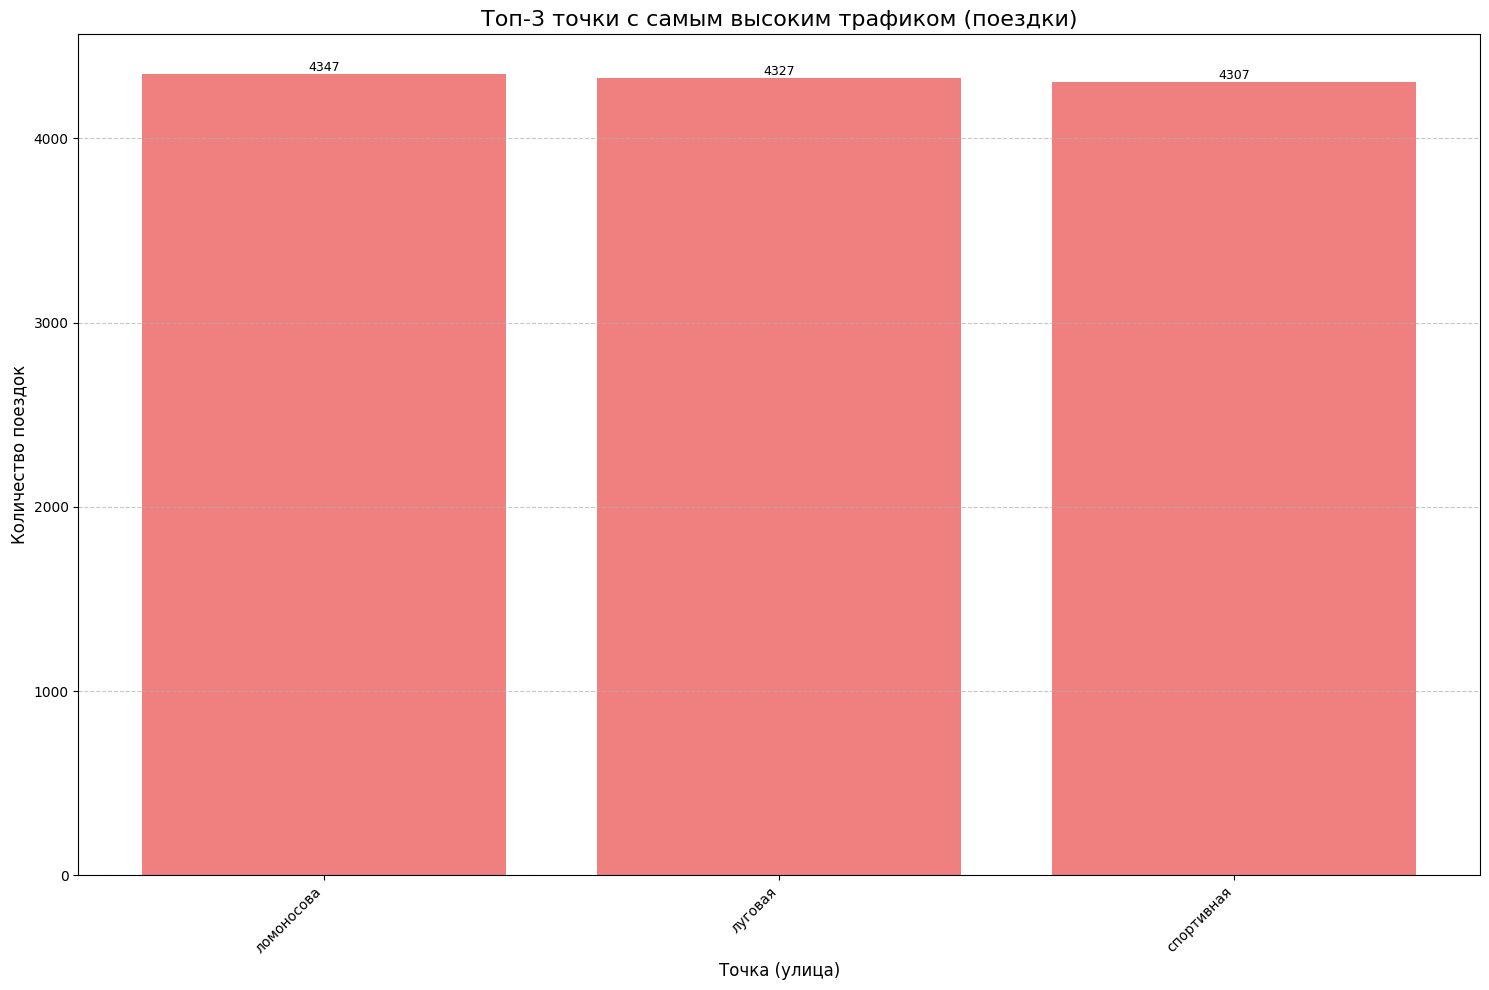

In [71]:
import matplotlib.pyplot as plt

# Сортируем данные по количеству поездок и оставляем топ-3 локации
top_3_traffic = all_trafic.nlargest(3, 'turn_per_day')

# Строим график
plt.figure(figsize=(15, 10))
bars = plt.bar(top_3_traffic.index, top_3_traffic['turn_per_day'], color='lightcoral')

# Подписи на столбиках
for bar in bars:
    height = bar.get_height()  # Получаем высоту столбика (это количество поездок для конкретной локации)
    # Размещаем текст в центре столбика
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

# Оформление графика
plt.title('Топ-3 точки с самым высоким трафиком (поездки)', fontsize=16)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворот подписей по оси X
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Сетка только по оси Y
plt.tight_layout()  # Автоматическая подгонка элементов графика

# Отображение графика
plt.show()


**Сортировка по количеству поездок:
Построение столбчатой диаграммы:
Подписи над столбиками:
В цикле for bar in bars добавляем текстовые подписи прямо на столбики, указывая точное количество поездок для каждой локации. Подпись позиционируется по центру столбика и немного выше его вершины (для улучшенной читаемости).
Оформление графика:
Устанавливаем заголовок графика и подписи для осей с помощью plt.title(), plt.xlabel() и plt.ylabel().
Поворот подписей на оси X с помощью plt.xticks(rotation=45), чтобы текст был легче читаемым.
Добавляем сетку для оси Y (plt.grid(axis='y')), чтобы легче было ориентироваться в значениях.**

**Стоит ли закрывать некоторые точки?**

In [72]:
weekdays = {}

for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|██████████| 101/101 [00:00<00:00, 319.86it/s]


**Цикл группирует данные по дням недели с помощью метода groupby('weekday'). Затем фильтрует эти группы, оставляя только те записи, где сезон Start Season равен "Весна".
Результат сохраняется в словарь weekdays, где ключ — это день недели, а значение — это данные, соответствующие этому дню.
Количество поездок по каждой начальной локации (inter) и по каждой конечной локации (leave).
Суммарную стоимость поездок по каждой начальной локации.
Все эти данные объединяются в один датафрейм fin, в котором также рассчитывается общее количество поездок (turn_per_day), полученное как сумма inter и leave.**

In [73]:
dat = dat.sort_values(by='Trip Cost', ascending=False)
dat

,Trip Cost,inter,leave,turn_per_day
Start Location,,,,
луговая,135291.033333,776,723,1499
восточная,131901.650000,761,769,1530
ломоносова,129770.683333,763,748,1511
буденного,127965.333333,738,790,1528
спортивная,123999.266667,713,791,1504
...,...,...,...,...
набережная,45422.066667,268,268,536
матросова,45201.950000,268,306,574
строителей,44836.933333,255,295,550


Можес использовать эти данные для оптимизации маршрутов самокатов, улучшения распределения самокатов по популярным точкам и планирования затрат.
Также  исследовать, как каждый день недели влияет на поведение пользователей, если будет произведена дополнительная агрегация по дням недели или другим временным меткам.

In [74]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [75]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [76]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [77]:
un_popular

Index(['почтовая', 'сиреневая', 'дружбы', 'дзержинского', 'пролетарская',
       'набережная', 'матросова', 'строителей', 'мира', 'гоголя'],
      dtype='object', name='Start Location')

In [78]:
sum(dat['Trip Cost'][:])

5893908.383333332

In [79]:
sum(dat['Trip Cost'][:19])

1918833.8000000003

In [80]:
sum(dat['Trip Cost'][-19:])

874819.8666666666

In [81]:
(sum(dat['Trip Cost'][:19]) / sum(dat['Trip Cost'][:])) * 100

32.556220341429764

In [82]:
(sum(dat['Trip Cost'][-19:]) / sum(dat['Trip Cost'][:])) * 100

14.842780202360517

In [83]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['End Location'].unique()

    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['End Location'] == end_loc]

        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('Start Location').size().reset_index(name='trips')

        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)

        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)

        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(df)


Мы получаем все уникальные значения в столбце End Location, который представляет конечные локации самокатов. Это нужно для того, чтобы понять, на какие локации чаще всего приезжают самокаты.

In [84]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [85]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
    for v1 in v:
        reversed_dict[v1] = k

Группировка по району и извлечение уникальных локаций старта
Преобразование датафрейма и добавление столбца с количеством локаций
Создание обратного словаря


In [86]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

луговая
  Start Location  trips  percent         district
0      восточная     57      2.7      октябрьский
1        луговая     52      2.5      октябрьский
2        майская     48      2.3      октябрьский
3      буденного     43      2.0      октябрьский
4     ломоносова     39      1.8      октябрьский
5     пионерская     39      1.8         заречный
6        садовая     39      1.8         заречный
7    октябрьская     37      1.7         заречный
8       школьная     37      1.7  северо-западный
9      шоссейная     35      1.6         заречный
восточная
  Start Location  trips  percent     district
0     спортивная     56      2.6  октябрьский
1     пионерская     53      2.5     заречный
2     ломоносова     48      2.2  октябрьский
3        майская     46      2.1  октябрьский
4      восточная     46      2.1  октябрьский
5        луговая     43      2.0  октябрьский
6      буденного     42      2.0  октябрьский
7  комсомольская     40      1.9     заречный
8         ленина  

Цикл по элементам списка popular.
Печать текущей локации.
Получение данных по текущей локации из словаря.
Добавление столбца с районом для каждой стартовой локации.
Печать первых 10 строк датафрейма.

In [87]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

почтовая
  Start Location  trips  percent         district
0        майская     26      3.3      октябрьский
1      буденного     20      2.6      октябрьский
2       западная     17      2.2        ленинский
3       трудовая     16      2.1      центральный
4   строительная     16      2.1  северо-западный
5        луговая     16      2.1      октябрьский
6     ломоносова     15      1.9      октябрьский
7     пионерская     14      1.8         заречный
8         чехова     14      1.8         заречный
9       школьная     14      1.8  северо-западный
сиреневая
  Start Location  trips  percent         district
0     спортивная     22      2.8      октябрьский
1     ломоносова     21      2.6      октябрьский
2      буденного     20      2.5      октябрьский
3          новая     16      2.0  северо-западный
4        майская     16      2.0      октябрьский
5         чехова     16      2.0         заречный
6      восточная     16      2.0      октябрьский
7       комарова     15      1.

In [88]:
for j in popular:
    print(reversed_dict[j])

октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
заречный
заречный
заречный
заречный


In [89]:
for j in un_popular:
    print(reversed_dict[j])

юго-восточный
юго-восточный
центральный
центральный
центральный
центральный
центральный
центральный
центральный
центральный


Вывод: не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

Самые популярные направления перемещения

In [90]:
route_counts = df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

most_popular_route = route_counts.sort_values(by='trips', ascending=False)

start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

,Start Location,End Location,trips
3256,луговая,спортивная,66
184,буденного,буденного,64
3347,майская,спортивная,60
490,восточная,луговая,57
6555,спортивная,восточная,56
6586,спортивная,майская,55
3165,ломоносова,спортивная,55
3277,майская,буденного,54
4827,пионерская,восточная,53
489,восточная,ломоносова,53


 Группировка данных по начальной и конечной локации с подсчетом количества поездок.Сортировка маршрутов по количеству поездок в убывающем порядке.Извлечение отдельных столбцов для использования.Вывод 10 самых популярных маршрутов

Есть ли необходимость перераспределять самокаты в конце дня?

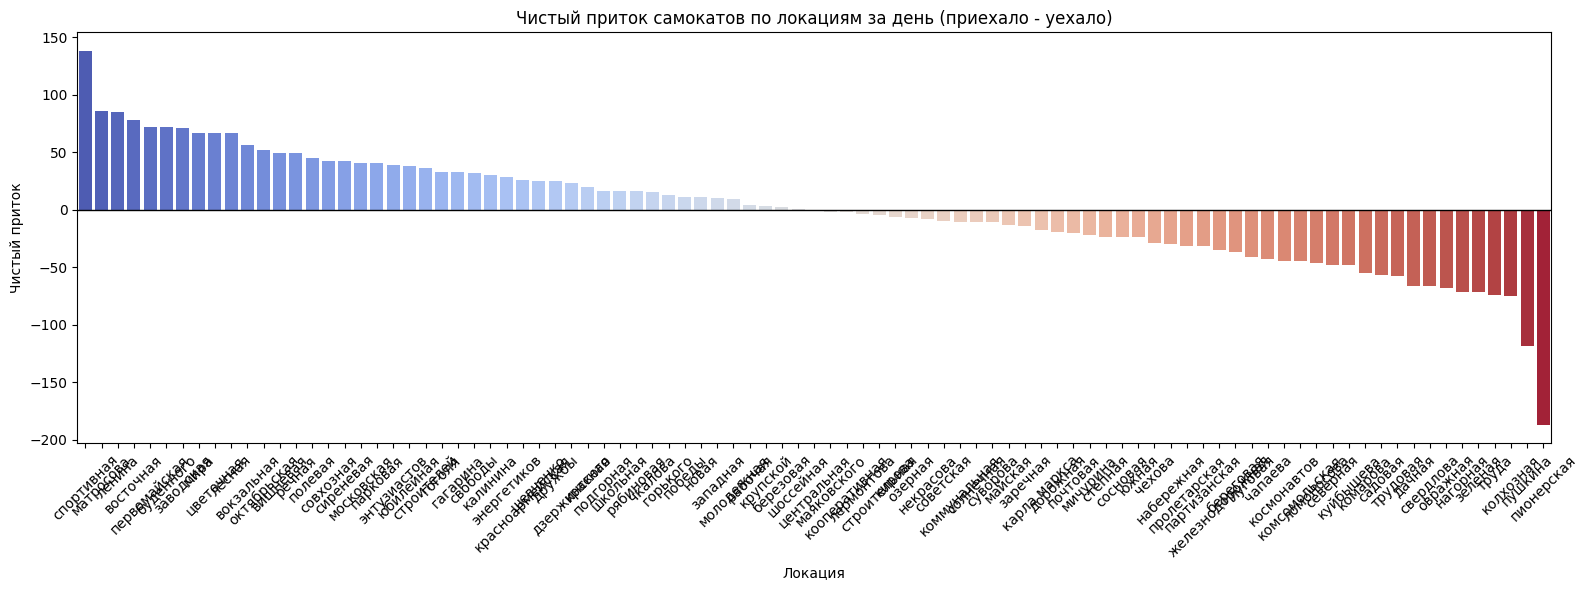

In [91]:
departures = df.groupby('Start Location').size().reset_index(name='departures')
arrivals = df.groupby('End Location').size().reset_index(name='arrivals')

balance = pd.merge(arrivals, departures,
                   left_on='End Location', right_on='Start Location',
                   how='outer')

balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

balance['net_flow'] = balance['arrivals'] - balance['departures']

balance = balance.sort_values(by='net_flow', ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


1. Группировка данных по начальной локации (отъезды)
2. Группировка данных по конечной локации (приезды)
3. Объединение данных о прибывших и уехавших
4. Заполнение пропущенных значений и корректировка столбцов
5. Заполнение пропущенных значений в столбцах "arrivals" и "departures"
6. Расчет чистого потока (приезды - отъезды)
7. Сортировка данных по чистому потоку
8. Построение графика

In [92]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

np.int64(1735)

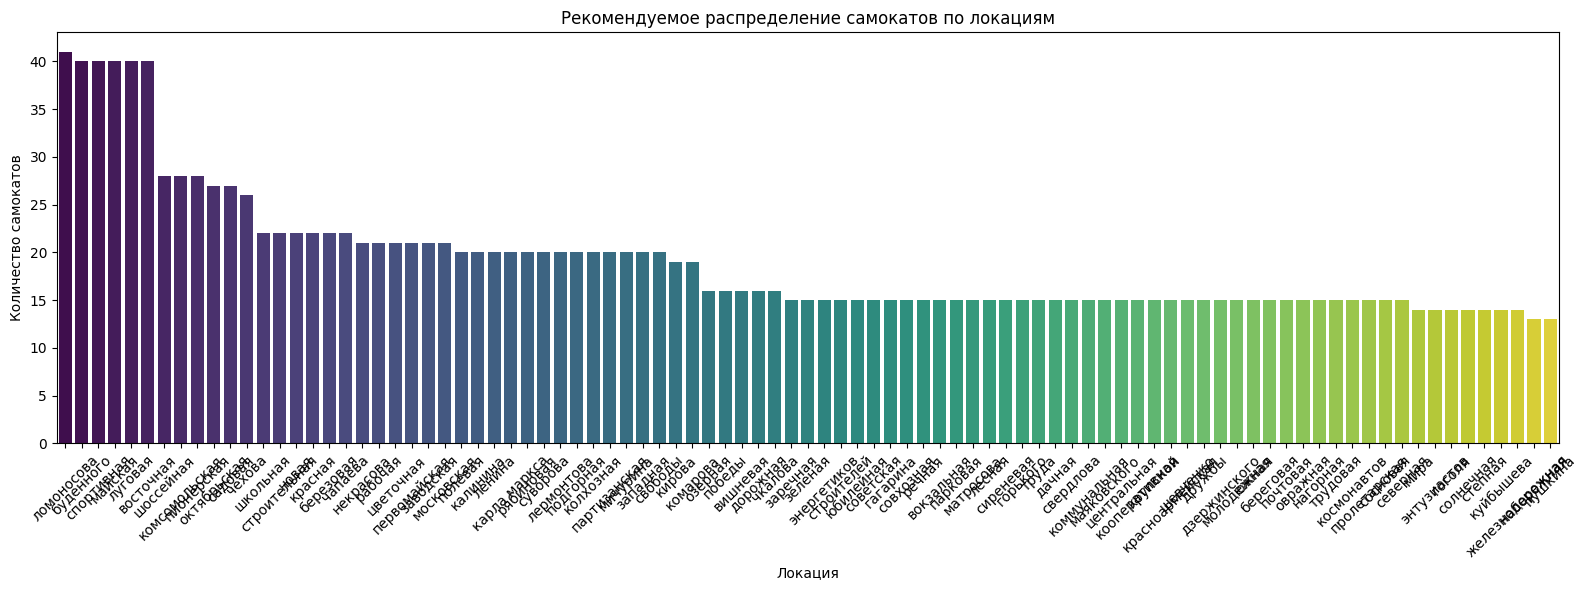

In [93]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)


diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:

    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)


final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


Добавление нового столбца для общего трафика. Добавление нового столбца для доли трафика каждой локации.Вычисление целевого количества самокатов для каждой локации. Корректировка распределения самокатов, если есть погрешности. Подготовка итогового распределения.Построение графика распределения самокатов.

In [94]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

np.True_

# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [95]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [96]:
df['weekday'] = df['Start Date'].dt.weekday
df['Start Month'] = df['Start Date'].apply(lambda x: x.month)
df['End Month'] = df['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)
df['Time start'] = df['Start Date'].dt.time
df['Time end'] = df['End Date'].dt.time
df['Trip Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6

df['Start Hour'] = df['Start Date'].dt.hour
df['Rate per Minute'] = df.apply(lambda row: get_rate(row['weekday'], row['Start Hour']), axis=1)
df['Trip Cost'] = df['Trip Duration'] * df['Rate per Minute']

In [98]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date
outflow = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')
outflow.rename(columns={'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Location': 'Location'}, inplace=True)
net_flow = pd.merge(inflow, outflow, on=['Date', 'Location'], how='outer').fillna(0)
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']
net_flow.sort_values(['Location', 'Date'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()


print(net_flow.head())


           Date   Location  inflow  outflow  net_change  cumsum
0    2023-04-22  береговая     7.0      5.0         2.0     2.0
91   2023-04-23  береговая     9.0      6.0         3.0     5.0
182  2023-04-24  береговая     7.0      5.0         2.0     7.0
273  2023-04-25  береговая     3.0      5.0        -2.0     5.0
364  2023-04-26  береговая     4.0      5.0        -1.0     4.0


 Преобразуем данные в нужный формат. Отток и приток по точкам (по каждой локации).Переименуем для объединения данных.Объединение данных о притоке и оттоке.Рассчитываем разницу в трафике. Накопительная сумма изменения потока по каждой точке.

Построение графика накопительной разницы по точкам

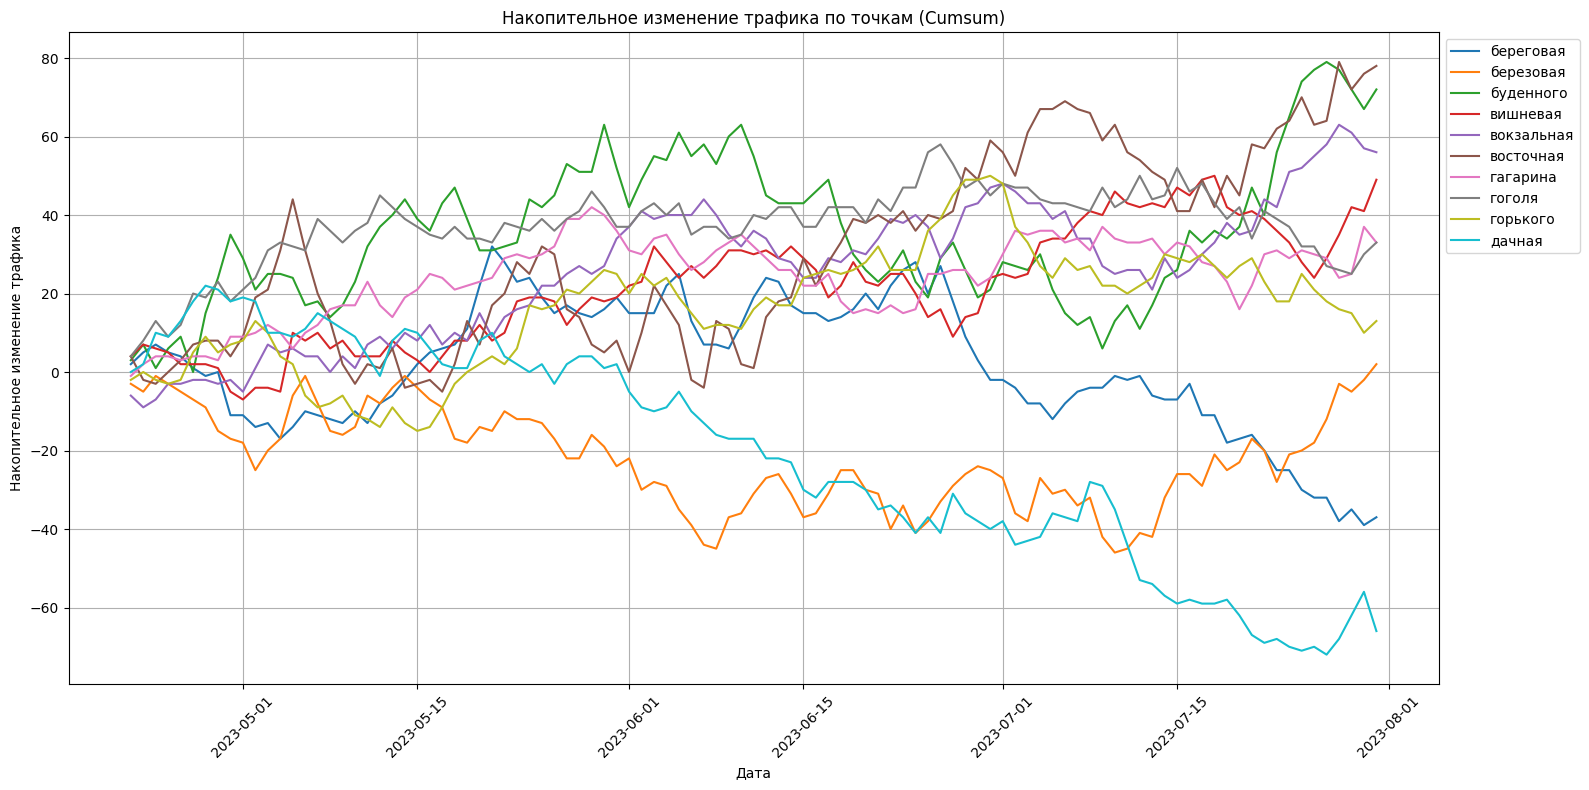

In [99]:
# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['Date'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2: Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме**

In [101]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters.sort_values(by='Required Scooters').head()

,Location,Required Scooters
22,комарова,-5.0
59,пушкина,-5.0
51,партизанская,-4.0
21,колхозная,-3.0
63,садовая,-3.0


Определение необходимого количества самокатов по районам

In [102]:
# Добавляем информацию о районах
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()
print(district_scooters.head())


    Start District  Required Scooters
0         заречный              168.0
1        ленинский              378.0
2      октябрьский              381.0
3  северо-западный              467.0
4      центральный              801.0


Построение графиков для самокатов по точкам и районам.

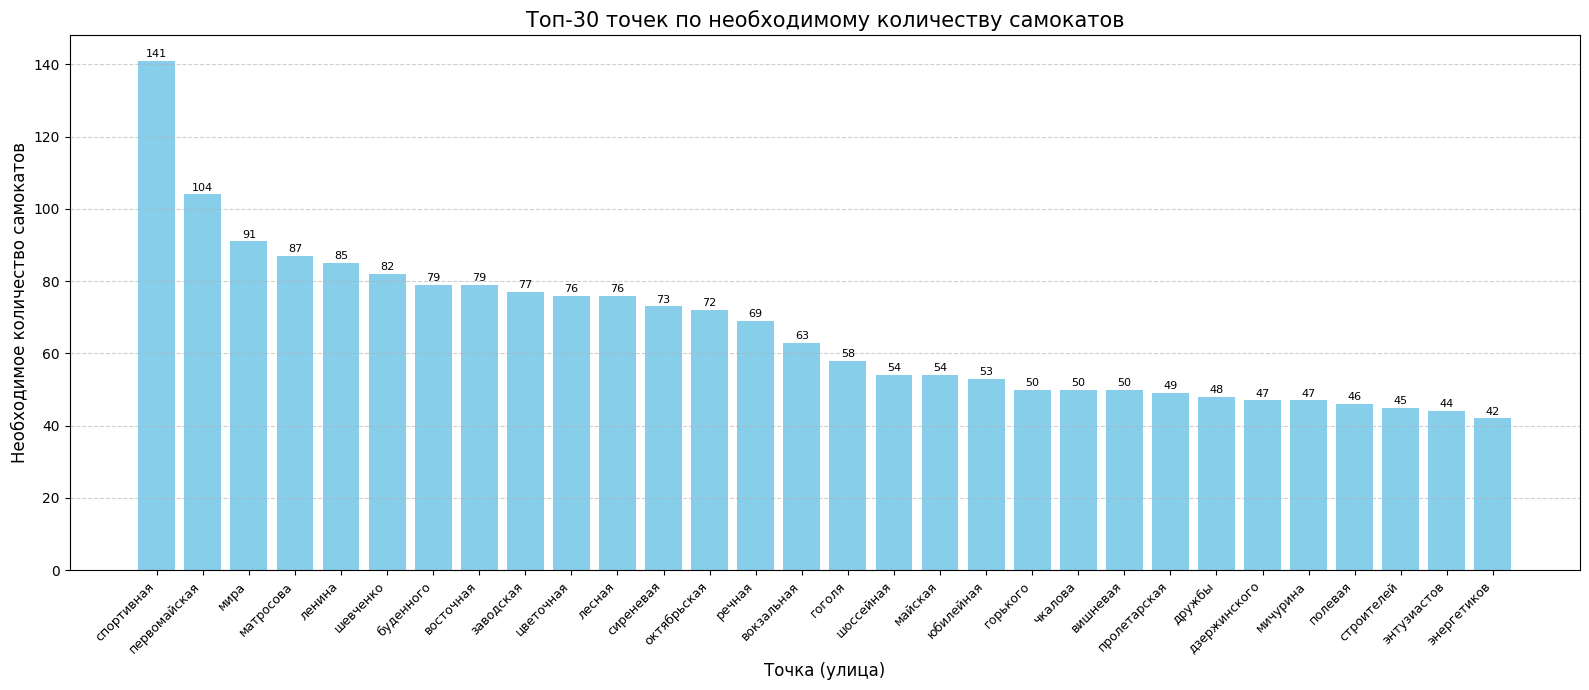

In [103]:
# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Таблица с почасовым трафиком (отъезды и приезды) для каждой точки

In [107]:
import pandas as pd

# Преобразуем столбцы в формат datetime
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Создаем столбец с часом поездки
df['Start Hour'] = df['Start Date'].dt.floor('H')  # Округляем время начала поездки до ближайшего часа
df['End Hour'] = df['End Date'].dt.floor('H')      # Округляем время конца поездки до ближайшего часа

# Группируем по точке отправления (Start Location) и часу начала (Start Hour) для отъездов
outflow = df.groupby(['Start Location', 'Start Hour']).size().reset_index(name='outflow')

# Группируем по точке назначения (End Location) и часу окончания (End Hour) для приездов
inflow = df.groupby(['End Location', 'End Hour']).size().reset_index(name='inflow')

# Переименуем столбцы, чтобы объединить данные
outflow.rename(columns={'Start Location': 'Location', 'Start Hour': 'Hour'}, inplace=True)
inflow.rename(columns={'End Location': 'Location', 'End Hour': 'Hour'}, inplace=True)

# Объединяем данные о притоке и оттоке по локации и времени
traffic = pd.merge(outflow, inflow, on=['Location', 'Hour'], how='outer').fillna(0)

# Рассчитываем чистый трафик для каждой локации по каждому часу
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# Просмотр результатов
print(traffic.head())


    Location                Hour  outflow  inflow  net_traffic
0  береговая 2023-04-22 10:00:00      0.0     1.0          1.0
1  береговая 2023-04-22 13:00:00      1.0     0.0         -1.0
2  береговая 2023-04-22 14:00:00      2.0     0.0         -2.0
3  береговая 2023-04-22 17:00:00      0.0     1.0          1.0
4  береговая 2023-04-22 18:00:00      2.0     1.0         -1.0


Используя группировку, посчитаем количество поездок для каждой локации (как для отъездов, так и для приездов) по часам. Это делается с помощью метода resample, который позволяет ресемплировать данные по заданному интервалу времени (в нашем случае — по часам).Мы получим таблицу с количеством отъездов и приездов для каждой локации по каждому часу.

**Вывод**: На локации «береговая» наблюдается отрицательный чистый поток в течение дня – это значит, что оттуда уезжает больше самокатов, чем приезжает.

Самые активные часы отъездов:

В 14:00 — сразу 2 отъезда, ни одного приезда → чистый отток -2.

В 18:00 — тоже 2 отъезда, но хотя бы 1 приезд → чистый отток -1.

Часы, когда был чистый приток:

В 10:00 и в 17:00 — +1 самокат прибыл на точку в каждом из этих часов.

В целом, за этот день на локации «береговая» ушло больше самокатов, чем вернулось, что может говорить о её популярности как точки старта, но не финиша.

**почасовой трафик по точкам**

In [110]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Выделяем час (обрезаем до часа)
df['Start Hour'] = df['Start Date'].dt.floor('H')
df['End Hour'] = df['End Date'].dt.floor('H')
outflow = df.groupby(['Start Hour', 'Start Location']).size().reset_index(name='outflow')
outflow = outflow.rename(columns={'Start Hour': 'Hour', 'Start Location': 'Location'})
inflow = df.groupby(['End Hour', 'End Location']).size().reset_index(name='inflow')
inflow = inflow.rename(columns={'End Hour': 'Hour', 'End Location': 'Location'})
# Объединяем приток и отток
hourly_traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# Добавляем столбец с чистым потоком
hourly_traffic['net_traffic'] = hourly_traffic['inflow'] - hourly_traffic['outflow']
hourly_traffic


,Hour,Location,inflow,outflow,net_traffic
0,2023-04-22 09:00:00,буденного,0.0,2.0,-2.0
1,2023-04-22 09:00:00,восточная,0.0,1.0,-1.0
2,2023-04-22 09:00:00,гоголя,1.0,0.0,1.0
3,2023-04-22 09:00:00,западная,2.0,0.0,2.0
4,2023-04-22 09:00:00,зеленая,0.0,1.0,-1.0
...,...,...,...,...,...
104302,2023-08-01 00:00:00,садовая,1.0,0.0,1.0
104303,2023-08-01 00:00:00,суворова,1.0,0.0,1.0
104304,2023-08-01 00:00:00,чкалова,1.0,0.0,1.0
104305,2023-08-01 00:00:00,шевченко,1.0,0.0,1.0


**АНАЛИЗ:** 1. Суммарный трафик (по всем точкам и времени)
Суммарный inflow (приезды): это общее число самокатов, которые завершили поездку на точке.
Суммарный outflow (отъезды): общее число самокатов, которые начали поездку с точки.
Если сумма inflow = сумма outflow → система сбалансирована.
Но если наблюдается:
Переизбыток inflow — точки перегружаются (может не хватать места, парковок).
Переизбыток outflow — точки опустошаются (нет самокатов для старта поездки).

2. Трафик по отдельным точкам
Можно выделить три типа точек:
Сбалансированные точки (net_traffic ≈ 0)
Пример: точки, где inflow и outflow примерно равны.
Такие локации не требуют регулярного вмешательства, они “самообслуживаются”.
Притягивающие точки (net_traffic > 0)
Пример: точки, где приезжает больше, чем уезжает.
Возможные причины: Жилые районы вечером
Риски: переполненность и нехватка свободного места.

Рекомендации:
Добавить парковочные зоны
Планировать вывоз самокатов в утренние/вечерние часы
Опустошаемые точки (net_traffic < 0)
Пример: точки, где уезжают чаще, чем приезжают.
Возможные причины:Жилые районы утром

Центр города, парки, ТЦ — в начале дня
Рекомендации:
Подвозить самокаты с утра
Следить за доступностью в часы пик

Пики утренние (7:00–9:00) — люди уезжают из спальных районов.
Пики вечерние (17:00–20:00) — возвращаются обратно.
В течение дня – относительно спокойный трафик с локальными всплесками.




**Разница отъезды и приезды**

In [113]:
# 1. Смещаем время на 6 часов назад, чтобы день начинался с 6:00
df['Start Date Shifted'] = df['Start Date'] - pd.Timedelta(hours=6)
df['End Date Shifted'] = df['End Date'] - pd.Timedelta(hours=6)

# 2. Округляем время до часа
df['Start Hour'] = df['Start Date Shifted'].dt.floor('h')
df['End Hour'] = df['End Date Shifted'].dt.floor('h')

# 3. Группируем по часу и локации
outflow = df.groupby(['Start Hour', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['End Hour', 'End Location']).size().reset_index(name='inflow')

# 4. Переименуем колонки для объединения
outflow.rename(columns={'Start Hour': 'Hour', 'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Hour': 'Hour', 'End Location': 'Location'}, inplace=True)

# 5. Объединяем приезды и отъезды
traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# 6. Считаем чистый трафик (приехало - уехало)
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# 7. Группируем по дате и локации
traffic['Date'] = traffic['Hour'].dt.date
daily_net = traffic.groupby(['Date', 'Location'])['net_traffic'].sum().reset_index()

# 8. Считаем накопительную сумму по каждой локации (динамика самокатов)
daily_net['cumsum'] = daily_net.groupby('Location')['net_traffic'].cumsum()
daily_net

,Date,Location,net_traffic,cumsum
0,2023-04-22,береговая,2.0,2.0
1,2023-04-22,березовая,-3.0,-3.0
2,2023-04-22,буденного,3.0,3.0
3,2023-04-22,вишневая,5.0,5.0
4,2023-04-22,вокзальная,-6.0,-6.0
...,...,...,...,...
9186,2023-07-31,шоссейная,3.0,1.0
9187,2023-07-31,энергетиков,-2.0,28.0
9188,2023-07-31,энтузиастов,-3.0,39.0
9189,2023-07-31,юбилейная,-3.0,38.0


Выводы:
Отрицательные cumsum у ряда точек (например, березовая, вокзальная, южная) указывают на постоянный отток самокатов. Эти точки, скорее всего, источники поездок — их нужно регулярно пополнять.

Положительный cumsum (например, энтузиастов, энергетиков) говорит о накоплении самокатов — это точки прибытия, где со временем будет перенасыщение.

Колебания без сильного тренда могут свидетельствовать о балансных точках, где вход и выход примерно равны.

**Минимумы для каждой точки**

In [114]:
# Ресемплирование по дате, для каждой локации находим минимум cumsum по дням
daily_min_cumsum = net_flow.groupby(['Location', 'Date'])['cumsum'].min().reset_index()

# Усреднение по локациям
location_min_cumsum = daily_min_cumsum.groupby('Location')['cumsum'].mean().reset_index()

# Сортировка по возрастанию, чтобы определить точки с наименьшими накопленными значениями
location_min_cumsum_sorted = location_min_cumsum.sort_values(by='cumsum', ascending=True)

# Просмотр результатов
print(location_min_cumsum_sorted.head())


      Location     cumsum
53  пионерская -99.633663
59     пушкина -60.405941
77       труда -53.950495
47    овражная -44.158416
35     луговая -42.128713


**Локации с наибольшими отрицательными значениями cumsum:**

Пионерская (-99.63), Пушкина (-60.41), Труда (-53.95), Овражная (-44.16) и Луговая (-42.13) — это точки, где чаще всего происходит отток самокатов.

Эти локации имеют самые низкие (отрицательные) значения накопленного трафика, что может свидетельствовать о том, что на этих точках количество самокатов обычно уменьшается, а это указывает на потребность в их пополнении.

Распределение оттока:

Понижение накопленного трафика в этих локациях может происходить в моменты, когда самокаты активно отъезжают в другие точки, и данные локации оказываются недостаточно обеспеченными.

**Рекомендации:**
Регулярное пополнение:
Локации с такими минимальными значениями трафика явно нуждаются в регулярном пополнении самокатов, особенно в часы пикового спроса (например, утром). Эти локации, возможно, не справляются с объемом потребности и имеют постоянный отток.

Рекомендуется:
Увеличить пополнение самокатов в эти точки перед утренними и вечерними пиками, когда самокаты могут быть востребованы для поездок.

Анализ потребности в самокатах:
Возможно, стоит периодически проверять прогнозируемый трафик для этих локаций, основываясь на внешних данных, таких как плотность населения, инфраструктура и популярность районов.

Могут быть ситуации, когда количество самокатов в этих локациях избыточно уменьшается из-за постоянного отъезда, что говорит о том, что надо заранее учитывать логистику для равномерного распределения.

Перераспределение избыточных самокатов:
Можно использовать информацию о минимальных значениях накопленного трафика для перераспределения самокатов между точками, где происходит значительный отток. Это позволит минимизировать нехватку самокатов в определенных районах.

Рекомендуется:
Выстроить систему логистики для динамического перераспределения самокатов с точек с избыточным количеством (например, с точек с положительным cumsum) в эти "нуждающиеся" локации.

Учет дня недели и времени суток:
Нужно проводить дополнительный анализ по дням недели и времени суток, чтобы определить, когда именно в этих локациях происходит наибольший отток, и использовать данные для оптимизации логистики.

**Заключение:**
На основе текущего анализа видно, что локации с минимальными значениями cumsum (отрицательным накопленным трафиком) нуждаются в более частом пополнении. Рекомендуется организовать регулярное пополнение самокатов на этих точках в часы пик, а также пересматривать распределение самокатов в зависимости от спроса и времени суток.

Используем группировку по локации и дате для вычисления минимальных значений накопленного трафика (cumsum).

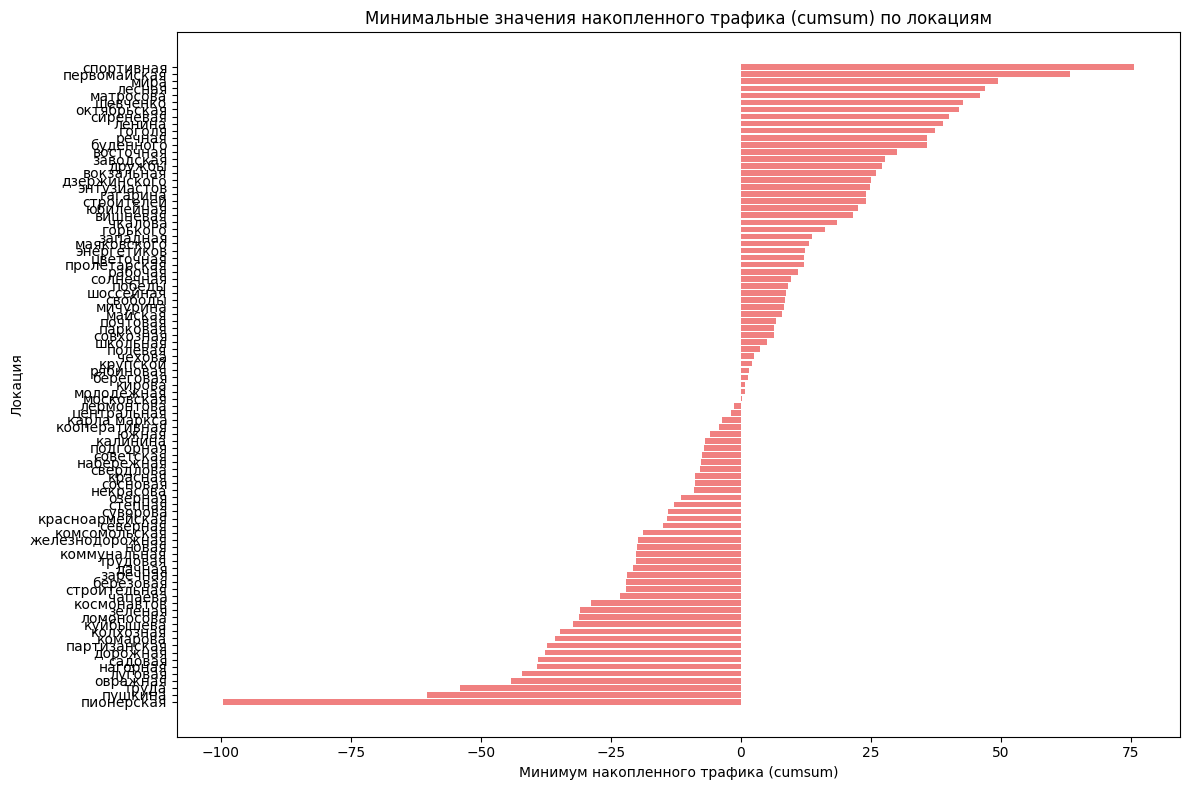

In [115]:
import matplotlib.pyplot as plt

# Построение графика минимальных значений cumsum по локациям
plt.figure(figsize=(12, 8))
plt.barh(location_min_cumsum_sorted['Location'], location_min_cumsum_sorted['cumsum'], color='lightcoral')
plt.xlabel('Минимум накопленного трафика (cumsum)')
plt.ylabel('Локация')
plt.title('Минимальные значения накопленного трафика (cumsum) по локациям')
plt.tight_layout()
plt.show()


График визуализирует минимальные значения накопленного трафика по каждой локации, что позволяет лучше понять, где происходят самые большие изменения (например, отток самокатов).

Точки с наибольшим отрицательным значением cumsum будут находиться внизу графика, а те, где отрицательные значения минимальны (или даже положительные), — в верхней части графика.

Полезность графика:

Этот график наглядно показывает, в каких точках происходит наибольший отток самокатов (самые отрицательные значения cumsum).

Это помогает сразу выделить проблемные локации, которые требуют особого внимания (например, дополнительного пополнения самокатов в эти точки или перераспределения).

Рекомендации:

Для локаций с наиболее отрицательным значением cumsum (которые находятся в нижней части графика) следует проанализировать причину такого оттока и предпринять меры для улучшения ситуации. Например, нужно обеспечить регулярное пополнение этих локаций или пересмотреть маршруты перемещения самокатов.

Вывод:График дает наглядное представление о том, где происходят наибольшие изменения в накопленном трафике, позволяя сделать выводы о локациях, которые нуждаются в дополнительном внимании.

 Cколько самокатов требуется для покрытия ежедневного спроса в различных районах города

In [118]:
import pandas as pd

# Пример DataFrame (если у вас есть свои данные, замените на ваш DataFrame)
df = pd.DataFrame({
    'Date': pd.date_range(start='2023-04-22', periods=10, freq='D'),
    'Location': ['Location1', 'Location2', 'Location1', 'Location3', 'Location2', 'Location1', 'Location3', 'Location2', 'Location1', 'Location3'],
    'inflow': [10, 5, 12, 3, 8, 10, 6, 9, 7, 4],
    'outflow': [5, 3, 8, 2, 4, 6, 3, 5, 3, 6]
})

# Преобразуем столбец Date в формат даты
df['Date'] = pd.to_datetime(df['Date']).dt.date

# Группируем по дате и локации, считаем приток и отток
daily_flow = df.groupby(['Date', 'Location']).agg({'inflow': 'sum', 'outflow': 'sum'}).reset_index()

# Рассчитываем чистое изменение потока (net_flow)
daily_flow['net_flow'] = daily_flow['inflow'] - daily_flow['outflow']


In [119]:
# Рассчитываем минимальные и максимальные значения чистого потока для каждой локации
location_requirements = daily_flow.groupby('Location').agg(
    min_net_flow=('net_flow', 'min'),
    max_net_flow=('net_flow', 'max')
).reset_index()

# Рассчитываем необходимое количество самокатов для каждой локации
location_requirements['required_scooters'] = location_requirements[['min_net_flow', 'max_net_flow']].mean(axis=1).round().astype(int)

print(location_requirements)


    Location  min_net_flow  max_net_flow  required_scooters
0  Location1             4             5                  4
1  Location2             2             4                  3
2  Location3            -2             3                  0


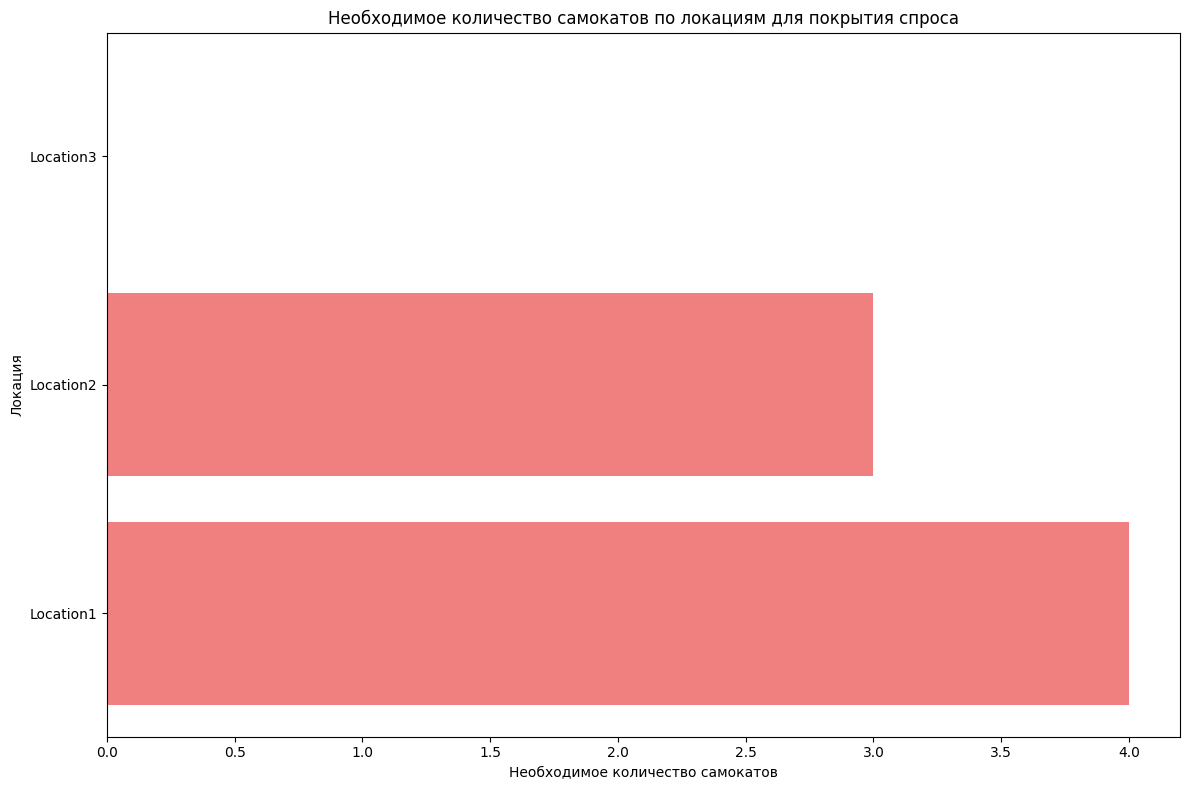

In [122]:
import matplotlib.pyplot as plt

# Построение графика для локаций
plt.figure(figsize=(12, 8))
plt.barh(location_requirements['Location'], location_requirements['required_scooters'], color='lightcoral')
plt.xlabel('Необходимое количество самокатов')
plt.ylabel('Локация')
plt.title('Необходимое количество самокатов по локациям для покрытия спроса')
plt.tight_layout()
plt.show()


Оптимизация распределения: Вычисленное количество самокатов для каждого района может быть использовано для оптимизации распределения самокатов по всему городу, обеспечивая нужное количество для поддержания бесперебойной работы в течение дня.

Анализ сезонности: Для лучшего прогноза количества самокатов стоит учитывать сезонные колебания. Если, например, в летнее время наблюдается увеличенный трафик, можно рассчитать отдельное количество самокатов для каждого сезона.

Обновление на основе данных: Регулярно обновляйте расчет на основе новых данных, чтобы скорректировать количество самокатов в реальном времени.

# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

* Нулевая - Влияет ли солнечность погоды на длину поездки?
* Альернатива - Солнечность погоды не влияет на длину поездки.

In [ ]:
df[['Sunshine Duration', 'Distance']]

In [ ]:
filtered = df[['Distance', 'Sunshine Duration']].dropna()
correlation, p_value = spearmanr(filtered['Sunshine Duration'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")


Нулевая гипотиза опровергнута, значит можем утверждать, что солнечность погоды не влияет на длину поездки

* Нулевая - Влияет ли день недели на длину поездки?
* Альернатива - День недели не влияет на длину поездки.

In [ ]:
filtered = df[['Distance', 'weekday']].dropna()
correlation, p_value = spearmanr(filtered['weekday'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")

Вывод: да, есть сильная зависимость между днем недели и длиной поездки

* Нулевая - Падает ли спрос на самокаты в середине недели и происходит из-за постоянного ухудшения погоды именно в эти дни
* Альернатива - спрос не падает в середине недели из-за постоянного ухудшения погоды

In [ ]:
# Вывести названия всех столбцов
print(df.columns)


In [ ]:
# Загрузка данных
df = pd.read_csv('weather.csv')

# Преобразуем дату и извлечем день недели
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['Weekday'] = df['Datetime'].dt.weekday  # 0 = понедельник, 6 = воскресенье

# Проверим, есть ли пропущенные значения в 'Weekday' и заменим их (если есть)
df['Weekday'] = df['Weekday'].fillna(-1).astype(int)  # -1 на случай NaN значений

# Преобразуем погодные столбцы в числовой формат
weather_columns = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заполним пропущенные значения средними
df[weather_columns] = df[weather_columns].fillna(df[weather_columns].mean())

# Группировка: средняя погода по дням недели
agg_df = df.groupby('Weekday').agg({
    'Temperature': 'mean',
    'Precipitation Total': 'mean',
    'Cloud Cover Total': 'mean',
    'Wind Speed': 'mean'
}).reset_index()

# Названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
agg_df['Weekday Name'] = agg_df['Weekday'].map(lambda x: day_names[int(x)] if x >= 0 and x < len(day_names) else 'Невалидный день')

# Визуализация: температура и осадки по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Temperature'], label='Температура (°C)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Precipitation Total'], label='Осадки (мм)', marker='s')
plt.title('Температура и осадки по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Визуализация: облачность и скорость ветра по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Cloud Cover Total'], label='Облачность (%)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Wind Speed'], label='Скорость ветра (м/с)', marker='s')
plt.title('Облачность и скорость ветра по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Корреляция между погодой
corr = agg_df[['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("Корреляция между погодными условиями:\n")
print(corr)


In [ ]:
# Загрузка данных
df = pd.read_csv('rides.csv')  # замените на имя вашего файла

# Преобразуем дату начала в datetime, если необходимо
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')

# Если нет числового дня недели — добавим его
if 'Weekday' not in df.columns:
    df['Weekday'] = df['Start Date'].dt.weekday  # 0 = Monday, 6 = Sunday

# Названия дней недели для красивой подписи
day_map = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df['Weekday Name'] = df['Weekday'].map(day_map)

# Группируем: считаем количество поездок на каждый день недели
trip_counts = df['Weekday Name'].value_counts().reindex(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])

# Визуализация
plt.figure(figsize=(10, 6))
trip_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Спрос на самокаты по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Загрузка данных
rides = pd.read_csv('rides.csv')
weather = pd.read_csv('weather.csv')

# Преобразуем даты
rides['Start Date'] = pd.to_datetime(rides['Start Date'], errors='coerce')
weather['Datetime'] = pd.to_datetime(weather['Datetime'], errors='coerce')

# Добавим колонку "Date" и "Weekday"
rides['Date'] = rides['Start Date'].dt.date
rides['Weekday'] = rides['Start Date'].dt.weekday  # 0=Пн
weather['Date'] = weather['Datetime'].dt.date
weather['Weekday'] = weather['Datetime'].dt.weekday

# Числовое преобразование погодных столбцов
weather_cols = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_cols:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

# Группировка: усреднённая погода по дню
weather_daily = weather.groupby(['Date', 'Weekday'])[weather_cols].mean().reset_index()

# Количество поездок по дате
rides_daily = rides.groupby(['Date', 'Weekday']).size().reset_index(name='Ride Count')

# Объединение данных
merged = pd.merge(rides_daily, weather_daily, on=['Date', 'Weekday'], how='inner')

# Добавим названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
merged['Weekday Name'] = merged['Weekday'].map(lambda x: day_names[x])

# --------------------
# 📊 Визуализация спроса
# --------------------
plt.figure(figsize=(10, 5))
merged.groupby('Weekday Name')['Ride Count'].mean().reindex(day_names).plot(kind='bar', color='skyblue')
plt.title("Средний спрос на самокаты по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее количество поездок")
plt.grid(axis='y')
plt.show()

# --------------------
# 🧪 Статистическая проверка гипотезы (t-test)
# --------------------
# Группы: середина недели (Вт, Ср, Чт) против остального времени
midweek = merged[merged['Weekday'].isin([1, 2, 3])]['Ride Count']
non_midweek = merged[~merged['Weekday'].isin([1, 2, 3])]['Ride Count']

t_stat, p_value = ttest_ind(midweek, non_midweek, equal_var=False)

print("Результаты t-теста:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")

# --------------------
# 📈 Корреляция погоды и спроса
# --------------------
corr = merged[['Ride Count', 'Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("\nКорреляция между погодными условиями и спросом на самокаты:")
print(corr['Ride Count'].sort_values(ascending=False))


Температура и осадки имеют положительную корреляцию (0.459). Это значит, что при повышении температуры количество поездок увеличивается, а при увеличении осадков — уменьшается.

Облачность и осадки также имеют отрицательную корреляцию с количеством поездок. То есть, когда облачность и осадки увеличиваются, количество поездок уменьшается.

Скорость ветра имеет слабую отрицательную корреляцию с количеством поездок (-0.197), что также может указывать на то, что при сильном ветре спрос на самокаты несколько снижается.

Вывод: спрос падает из-за ухудшения погоды в определенные дни недели

* Нулевая - все поездки на самокатах происходят в пределах одного района в пределах 1 района

* Альтернатива - Поездки на самокатах происходят не только в пределах одного района, и существует статистически значимая разница в распределении поездок между различными районами."

In [ ]:
start_counts = df['Start District'].value_counts()
end_counts = df['End District'].value_counts()

district_counts = (start_counts + end_counts).fillna(0)

# Определяем центр и окраины
threshold_center = district_counts.quantile(0.75)  # Верхние 25% - центр
threshold_outskirts = district_counts.quantile(0.25)  # Нижние 25% - окраины

districts = pd.DataFrame({'District': district_counts.index, 'Trips': district_counts.values})
districts['Category'] = 'Middle'
districts.loc[districts['Trips'] >= threshold_center, 'Category'] = 'Center'
districts.loc[districts['Trips'] <= threshold_outskirts, 'Category'] = 'Outskirts'
print(districts)

In [ ]:
# Настройки визуализации
plt.figure(figsize=(14, 6))
sns.barplot(data=districts.sort_values('Trips', ascending=False), x='District', y='Trips', hue='Category', dodge=False)
plt.title('Количество поездок по районам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Добавляем колонку: поездка внутри района или нет
df['Same District'] = df['Start District'] == df['End District']

# 2. Считаем общее количество поездок по каждому району
district_trip_counts = df.groupby('Start District').size().sort_values(ascending=False)

# 3. Рассчитываем долю поездок внутри района и между районами по каждому району
district_movement = df.groupby('Start District')['Same District'].value_counts(normalize=True).unstack().fillna(0)

# 4. Переименуем колонки для удобства
district_movement.columns = ['Between Districts', 'Within Same District']

# 5. Сортируем районы по количеству поездок
district_movement = district_movement.loc[district_trip_counts.index]

# 6. Построение графика
plt.figure(figsize=(14, 7))
district_movement[['Within Same District', 'Between Districts']].plot(kind='bar', stacked=True, color=['mediumseagreen', 'tomato'], figsize=(14,7))

# 7. Настройки графика
plt.title('Зависимость: Поездки внутри района vs между районами (по популярности районов)', fontsize=16)
plt.ylabel('Доля поездок', fontsize=12)
plt.xlabel('Районы', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Тип поездки', labels=['Внутри района', 'Между районами'])
plt.tight_layout()
plt.show()

Альтернативная гипотеза подтверждается, потому что:
Межрайонные поездки — это устойчивая часть всех поездок.
Для разных районов их доля значительно варьируется (в одних районах больше поездок внутри, в других — наоборот).

Вывод: Поездки на самокатах происходят не только в пределах одного района,

#### ГИПОТЕЗА 5: Нулевая гипотеза: День недели влияет на количество поездок: в выходные поездок больше

In [ ]:
# Словарь для замены номеров дней недели на названия
day_name_map = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Подсчёт, переименование и сортировка по значению
day_counts = df['Day of Week'].value_counts().rename(index=day_name_map)
day_counts = day_counts.sort_values(ascending=False)

# Вывод таблички
print(day_counts)

# Построение графика
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели (по возрастанию)')

for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.show()


Анализ распределения поездок по районам в будние и выходные дни.

In [ ]:
df['Day of Week'] = df['Start Date'].dt.weekday
df['Weekday'] = df['Start Date'].dt.weekday  # создаём колонку с номером дня недели
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)
print(district_day_type_distribution)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

#### Итог: Нулевая гипотеза подтверждена
#### День недели кардинально влияет на распределение поездок, в выходные дни и пятницу поездок наблюдается значительно больше

#### ГИПОТЕЗА 2: Нулевая гипотеза: В будние дни средняя скорость выше
#### Построение графика распределения поездок по дням недели со скоростью по каждому дню

In [ ]:
speed_by_weekday = df.groupby('Weekday')['Speed (km/h)'].agg(['mean', 'count']).reset_index()

weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['Weekday Name'] = speed_by_weekday['Weekday'].map(lambda x: weekday_names[x])

speed_by_weekday = speed_by_weekday.sort_values(by='Weekday')

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(speed_by_weekday['Weekday Name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['Weekday Name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df2 = df.copy()
# Преобразуем столбец Start Date в datetime
df2['Start Date'] = pd.to_datetime(df['Start Date'])

# Извлекаем день недели (0 - Понедельник, 6 - Воскресенье)
df2['Weekday'] = df2['Start Date'].dt.weekday

# Группируем по району, дню недели и считаем количество поездок и среднюю скорость
speed_by_weekday_district = df2.groupby(['Start District', 'Weekday'])['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday_district['Weekday Name'] = speed_by_weekday_district['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по району и дню недели
speed_by_weekday_district = speed_by_weekday_district.sort_values(by=['Start District', 'Weekday'])
# Размер графика
plt.figure(figsize=(12, 8))

# Список уникальных районов
districts = speed_by_weekday_district['Start District'].unique()

# Создадим графики для каждого района
for i, district in enumerate(districts):
    plt.subplot(len(districts), 2, 2 * i + 1)  # Строим подграфик для распределения поездок
    district_data = speed_by_weekday_district[speed_by_weekday_district['Start District'] == district]

    # Количество поездок
    plt.bar(district_data['Weekday Name'], district_data['count'], color='lightblue')
    plt.title(f'Поездки по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Количество поездок')
    plt.xticks(rotation=45)

    plt.subplot(len(districts), 2, 2 * i + 2)  # Строим подграфик для средней скорости
    # Средняя скорость
    plt.plot(district_data['Weekday Name'], district_data['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
    plt.title(f'Средняя скорость по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Средняя скорость (км/ч)')
    plt.xticks(rotation=45)

# Показать график
plt.tight_layout()
plt.show()


#### Итог: Нулевая гипотеза подтверждается.
#### В будние дни средняя скорость значительно больше. Предположение: В субботу и воскресенье пользователи предпочитают кататься по паркам, где есть ограничение по скорости + некуда торопиться, поездка превращается в прогулочную

1. Если цель акции — увеличить спрос:
-
Усильте рекламу акции:
Пользователи могут не знать о промокоде. Добавьте push-уведомления в понедельник утром.

Скорректируйте условия:
Например, сделайте скидку не только на старт (30 руб.), но и на минуты (например, 10% на всю поездк2. у).

Если цель — не терять пр- ибыль:
Отмените акцию в понедельник:
Раз спрос и так высок, акция лишь снижает доход (из-за бесплатного старта).

Перенесите акцию на менее популярные дни:
Например, на среду или пятницу, чтобы стимулировать спрос в "просадные" дни.

In [ ]:
import networkx as nx
district_flow = df.groupby(['Start District', 'End District']).size().reset_index(name='Trips')
# Построим граф направлений
G = nx.DiGraph()

# Добавим ребра с весами
for _, row in district_flow.iterrows():
    G.add_edge(row['Start District'], row['End District'], weight=row['Trips'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Толщина ребра пропорциональна количеству поездок
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, edge_color=weights, edge_cmap=plt.cm.Blues, width=2.0)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)
plt.title("Граф перемещений между районами")
plt.show()

# Пивот-таблица для тепловой карты
pivot_table = district_flow.pivot(index='Start District', columns='End District', values='Trips').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Количество поездок между районами")
plt.ylabel("Откуда")
plt.xlabel("Куда")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df

### Регрессионный анализ